# Unsupervised Learning: A Complete Guide
## Advanced Statistics with Projects

## Saad Ahmed Qadeer

## Table of Contents

1. What is Unsupervised Learning?
2. K-Means Clustering
3. Hierarchical Clustering
4. DBSCAN
5. Principal Component Analysis (PCA)
6. t-SNE
7. Autoencoders (brief introduction)
8. Gaussian Mixture Models
9. Comparing All Methods


---

## Section 0: Setup

Run this cell first. It installs and imports everything we need throughout the notebook.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons, make_circles, load_digits, make_classification
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

# Set a clean style for all plots
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f8f8'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4
plt.rcParams['font.size'] = 11
np.random.seed(42)

print('All libraries imported successfully.')

All libraries imported successfully.


---

## Section 1: What is Unsupervised Learning?

### The Core Idea

In supervised learning, every training example comes with a label. You show the model a picture of a cat, and you tell it: this is a cat. The model learns by comparing its predictions to those labels.

Unsupervised learning removes the labels entirely. You give the model raw data and say: find whatever structure exists here. The model has to discover patterns on its own, without being told what to look for.

This is actually closer to how humans learn in many situations. A child does not need to be told every time what a chair is. After seeing enough chairs, the child forms an internal concept of "chair" based on shared properties, without any explicit instruction.

### Why Does This Matter?

Labeled data is expensive and scarce. To train a supervised model, you need a human expert to label every example. In contrast, raw unlabeled data is abundant. The internet alone produces petabytes of it daily.

Unsupervised learning allows us to work with this raw data. We can:

- Discover natural groupings in customer data (market segmentation)
- Compress high-dimensional data into a smaller number of dimensions
- Detect anomalies by learning what "normal" looks like
- Understand the hidden structure in biological, financial, or social data

### The Two Main Families

Unsupervised learning broadly divides into two families:

**Clustering** asks: which data points belong together? The goal is to partition the data into groups such that points in the same group are more similar to each other than to points in other groups.

**Dimensionality Reduction** asks: how can we represent the data using fewer variables while keeping the important information? This is used for visualization, noise reduction, and as a preprocessing step before other algorithms.

We will cover both families in detail.

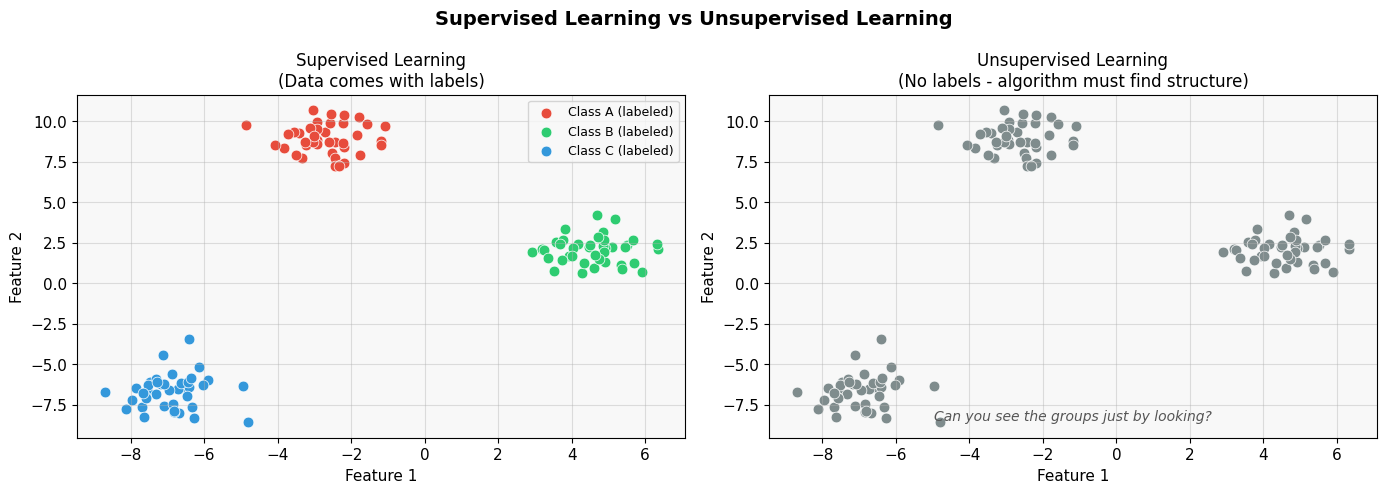

Notice: the data is identical. The only difference is whether we provide labels.


In [ ]:
# Visualization: Supervised vs Unsupervised learning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supervised Learning vs Unsupervised Learning', fontsize=14, fontweight='bold')

# Supervised: data with labels
X_sup, y_sup = make_blobs(n_samples=120, centers=3, cluster_std=0.9, random_state=42)
colors_sup = ['#e74c3c', '#2ecc71', '#3498db']
label_names = ['Class A (labeled)', 'Class B (labeled)', 'Class C (labeled)']
for i in range(3):
    axes[0].scatter(X_sup[y_sup == i, 0], X_sup[y_sup == i, 1],
                    c=colors_sup[i], label=label_names[i], s=60, edgecolors='white', linewidths=0.5)
axes[0].set_title('Supervised Learning\n(Data comes with labels)', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Unsupervised: same data but all one color (no labels)
axes[1].scatter(X_sup[:, 0], X_sup[:, 1], c='#7f8c8d', s=60, edgecolors='white', linewidths=0.5)
axes[1].set_title('Unsupervised Learning\n(No labels - algorithm must find structure)', fontsize=12)
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].text(0.5, 0.05, 'Can you see the groups just by looking?',
             transform=axes[1].transAxes, ha='center', fontsize=10,
             style='italic', color='#555555')

plt.tight_layout()
plt.show()
print('Notice: the data is identical. The only difference is whether we provide labels.')

---

## Section 2: K-Means Clustering

### The Intuition

K-Means is the most widely used clustering algorithm. Before explaining the math, here is the core intuition.

Imagine you have a map with many cities scattered across it. You want to build exactly K fire stations such that every city is covered by the nearest station. Where do you put the stations to minimize the total distance that any city has to travel to reach its station?

This is exactly the K-Means problem. The cities are your data points. The fire stations are the cluster centers (called centroids).

### The Algorithm Step by Step

K-Means is an iterative algorithm that alternates between two steps:

**Step 1 - Assignment:** Assign every data point to the nearest centroid. This partitions the data into K groups.

**Step 2 - Update:** Move each centroid to the mean (average) position of all points assigned to it.

Repeat until the assignments stop changing. This is called convergence.

### The Math

K-Means minimizes the within-cluster sum of squares (WCSS), also called inertia:

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

Where:
- $K$ is the number of clusters
- $C_k$ is the set of points in cluster $k$
- $\mu_k$ is the centroid (mean) of cluster $k$
- $\|x_i - \mu_k\|^2$ is the squared Euclidean distance from point $x_i$ to its centroid

**Assignment step** sets: $c^{(i)} = \arg\min_k \|x^{(i)} - \mu_k\|^2$

**Update step** sets: $\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i$

### Important Properties

- K-Means always converges, but may converge to a local minimum, not the global minimum. This is why it is common to run it multiple times with different initializations.
- The algorithm assumes clusters are roughly spherical and similar in size. It performs poorly on elongated or irregularly shaped clusters.
- You must specify K in advance. The Elbow Method helps choose a good K.

### Choosing K: The Elbow Method

Plot the WCSS (inertia) against the number of clusters K. As K increases, the inertia always decreases. But there is often a point where the improvement slows down sharply, forming an "elbow". This elbow suggests a natural number of clusters.

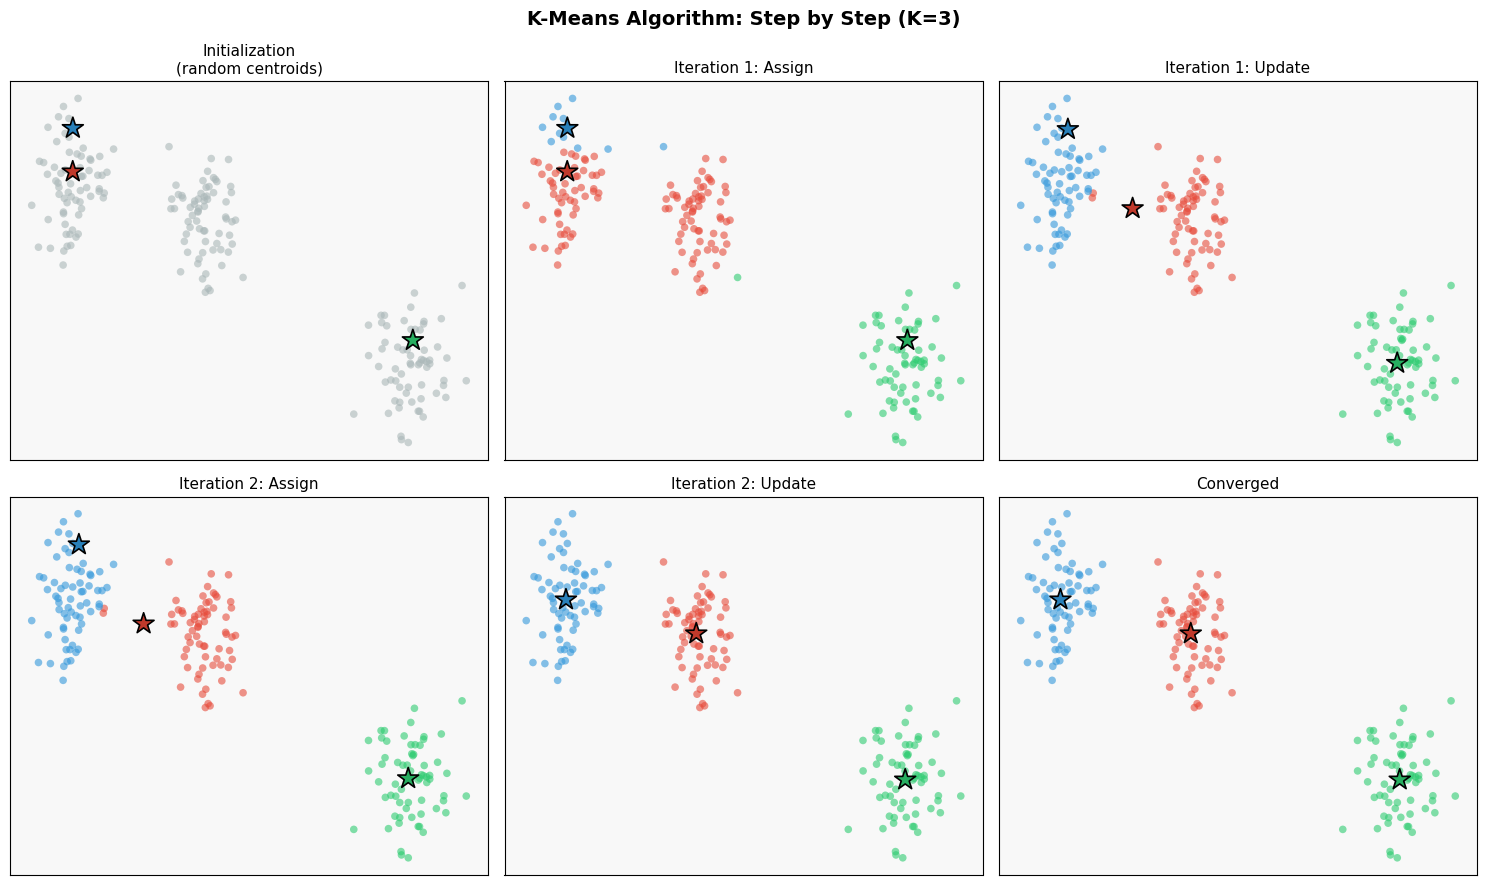

In [ ]:
# Step-by-step visualization of K-Means convergence
X_km, y_km = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=7)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('K-Means Algorithm: Step by Step (K=3)', fontsize=14, fontweight='bold')

colors = ['#e74c3c', '#2ecc71', '#3498db']
marker_colors = ['#c0392b', '#27ae60', '#2980b9']

# Random initialization
np.random.seed(10)
init_centroids = X_km[np.random.choice(len(X_km), 3, replace=False)]

def assign_clusters(X, centroids):
    distances = cdist(X, centroids)
    return np.argmin(distances, axis=1)

def update_centroids(X, labels, k):
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

centroids = init_centroids.copy()
steps = ['Initialization\n(random centroids)', 'Iteration 1: Assign', 'Iteration 1: Update',
         'Iteration 2: Assign', 'Iteration 2: Update', 'Converged']

all_labels = [None, None, None, None, None, None]
all_centroids = [centroids.copy()]

for step in range(5):
    if step % 2 == 0:
        lbl = assign_clusters(X_km, centroids)
        all_labels[step] = lbl
        all_centroids.append(centroids.copy())
    else:
        centroids = update_centroids(X_km, all_labels[step-1], 3)
        all_labels[step] = all_labels[step-1]
        all_centroids.append(centroids.copy())

all_labels[0] = np.zeros(len(X_km), dtype=int)  # no assignment yet
final_labels = assign_clusters(X_km, centroids)
all_labels[5] = final_labels
all_centroids.append(centroids.copy())

for idx, ax in enumerate(axes.flat):
    labels_to_show = all_labels[idx]
    cents = all_centroids[idx]
    if idx == 0:
        ax.scatter(X_km[:, 0], X_km[:, 1], c='#aab7b8', s=30, alpha=0.6, edgecolors='none')
    else:
        for k in range(3):
            mask = labels_to_show == k
            ax.scatter(X_km[mask, 0], X_km[mask, 1], c=colors[k], s=30, alpha=0.6, edgecolors='none')
    ax.scatter(cents[:, 0], cents[:, 1], c=marker_colors, s=250, marker='*',
               edgecolors='black', linewidths=1.2, zorder=5)
    ax.set_title(steps[idx], fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

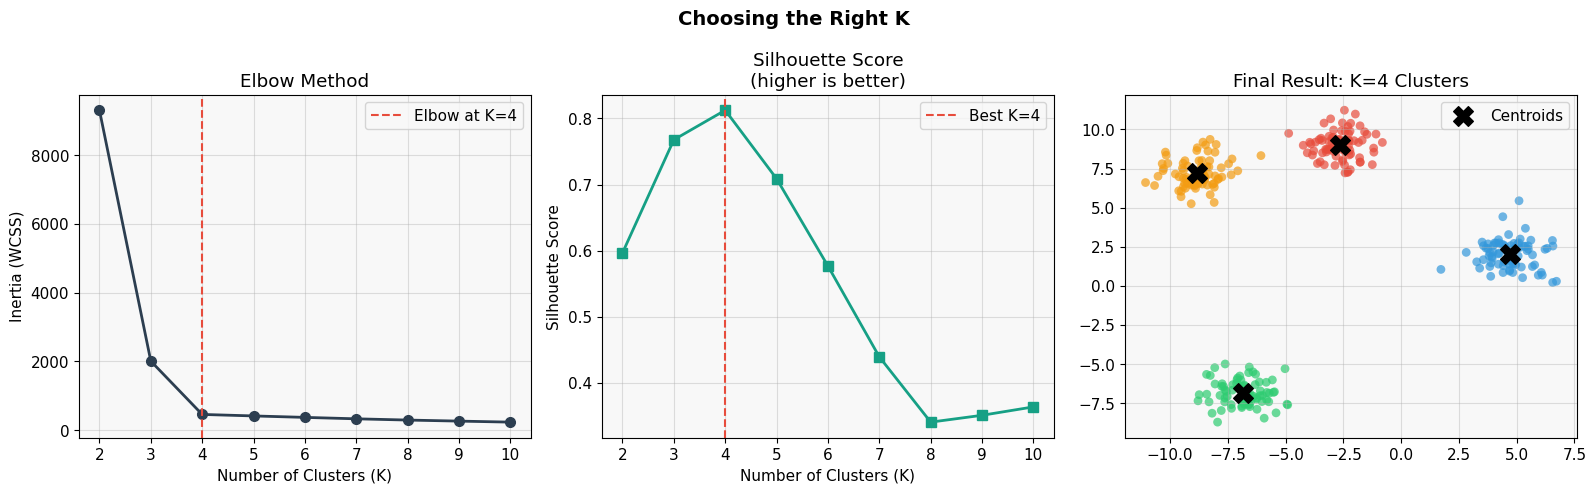

Best K by Silhouette: 4
Silhouette score at K=4: 0.8123

Silhouette score ranges from -1 to 1. Higher means better-defined clusters.


In [ ]:
# The Elbow Method for choosing K
X_elbow, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.9, random_state=42)

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_elbow)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_elbow, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Choosing the Right K', fontsize=14, fontweight='bold')

# Elbow plot
axes[0].plot(list(K_range), inertias, 'o-', color='#2c3e50', linewidth=2, markersize=7)
axes[0].axvline(x=4, color='#e74c3c', linestyle='--', linewidth=1.5, label='Elbow at K=4')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].legend()

# Silhouette plot
axes[1].plot(list(K_range), silhouettes, 's-', color='#16a085', linewidth=2, markersize=7)
best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Best K={best_k}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score\n(higher is better)')
axes[1].legend()

# Final clustering result
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
final_labels = km_final.fit_predict(X_elbow)
cluster_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
for k in range(4):
    mask = final_labels == k
    axes[2].scatter(X_elbow[mask, 0], X_elbow[mask, 1], c=cluster_colors[k], s=40, alpha=0.7, edgecolors='none')
axes[2].scatter(km_final.cluster_centers_[:, 0], km_final.cluster_centers_[:, 1],
                c='black', s=200, marker='X', zorder=5, label='Centroids')
axes[2].set_title('Final Result: K=4 Clusters')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Best K by Silhouette: {best_k}')
print(f'Silhouette score at K=4: {silhouettes[2]:.4f}')
print('\nSilhouette score ranges from -1 to 1. Higher means better-defined clusters.')

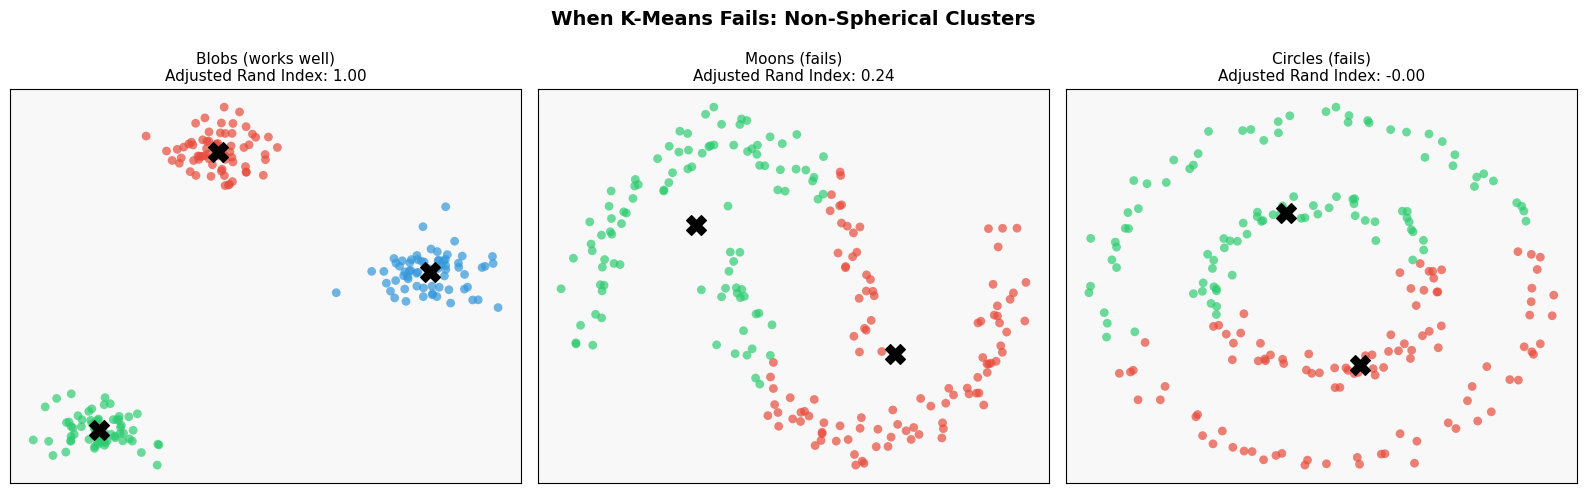

ARI = 1.0 means perfect clustering. ARI near 0 means essentially random.
K-Means fails on curved or ring-shaped clusters because it uses Euclidean distance.


In [ ]:
# K-Means weakness: non-spherical clusters
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('When K-Means Fails: Non-Spherical Clusters', fontsize=14, fontweight='bold')

datasets = [
    ('Blobs (works well)', *make_blobs(n_samples=200, centers=3, random_state=42)),
    ('Moons (fails)', *make_moons(n_samples=200, noise=0.08, random_state=42)),
    ('Circles (fails)', *make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=42))
]

for idx, (title, X_d, y_d) in enumerate(datasets):
    k = len(np.unique(y_d))
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    pred = km.fit_predict(X_d)
    correct = adjusted_rand_score(y_d, pred)
    for ci in range(k):
        axes[idx].scatter(X_d[pred == ci, 0], X_d[pred == ci, 1],
                          c=cluster_colors[ci], s=40, alpha=0.7, edgecolors='none')
    axes[idx].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                      c='black', s=200, marker='X', zorder=5)
    axes[idx].set_title(f'{title}\nAdjusted Rand Index: {correct:.2f}', fontsize=11)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

plt.tight_layout()
plt.show()
print('ARI = 1.0 means perfect clustering. ARI near 0 means essentially random.')
print('K-Means fails on curved or ring-shaped clusters because it uses Euclidean distance.')

---

## Section 3: Hierarchical Clustering

### The Intuition

Hierarchical clustering builds a tree-like structure (called a dendrogram) that represents how data points and groups relate to each other at different scales. Unlike K-Means, you do not need to specify the number of clusters in advance. You can choose the number after the fact by cutting the dendrogram at a certain level.

Think of it like a family tree. At the bottom, every individual is its own unit. As you go up, individuals merge into families, families merge into clans, clans into tribes, and so on. At any level of the tree, you have a particular clustering of the population.

### Agglomerative vs Divisive

There are two directions to build a hierarchy:

**Agglomerative (bottom-up):** Start with each point as its own cluster. At each step, merge the two closest clusters. Continue until all points are in one cluster. This is the most common approach.

**Divisive (top-down):** Start with all points in one cluster. At each step, split one cluster into two. Continue until every point is its own cluster. This is more complex and less commonly used.

### Linkage Criteria

The key decision in agglomerative clustering is how to measure the distance between two clusters (not two points). This is the linkage criterion:

**Single linkage:** Distance between clusters = distance between their closest points. Tends to produce long, chain-like clusters.

**Complete linkage:** Distance between clusters = distance between their farthest points. Tends to produce compact, roughly equal-sized clusters.

**Average linkage:** Distance between clusters = average distance between all pairs of points, one from each cluster. A compromise between single and complete.

**Ward's linkage:** Merge the two clusters that produce the smallest increase in total within-cluster variance. Generally produces the most compact and well-separated clusters. This is usually the default choice.

### The Dendrogram

A dendrogram shows the merging process. The x-axis shows the data points (or clusters). The y-axis shows the distance at which merges happen. A high horizontal bar means two groups that were very different got merged. To get K clusters, draw a horizontal line that cuts through exactly K vertical lines.

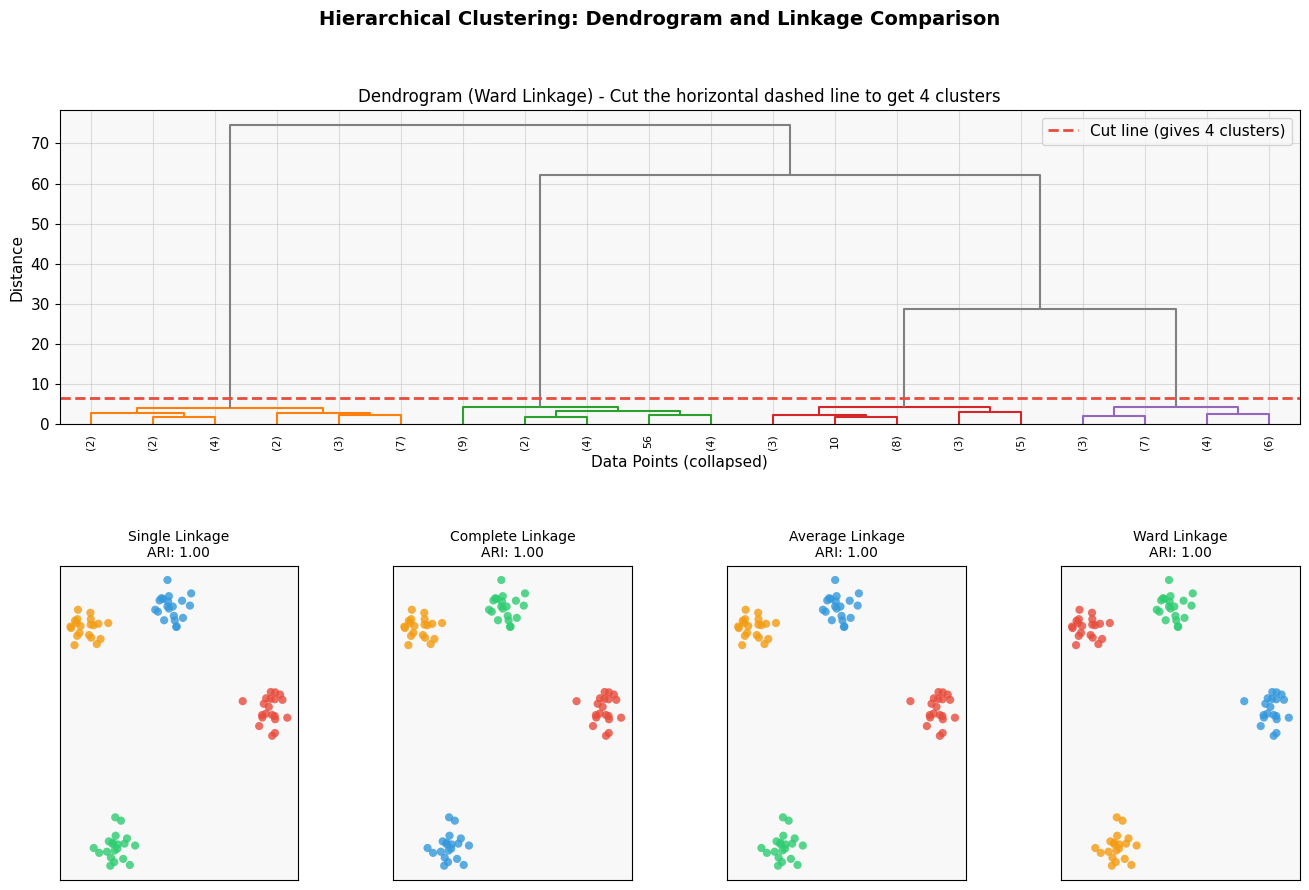

Ward linkage generally gives the most balanced, compact clusters.


In [ ]:
# Hierarchical clustering demonstration
X_hc, y_hc = make_blobs(n_samples=80, centers=4, cluster_std=0.8, random_state=42)

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.4)
fig.suptitle('Hierarchical Clustering: Dendrogram and Linkage Comparison', fontsize=14, fontweight='bold')

# Dendrogram
ax_dendro = fig.add_subplot(gs[0, :])
Z = linkage(X_hc, method='ward')
dend = dendrogram(Z, ax=ax_dendro, truncate_mode='lastp', p=20,
                  color_threshold=6.5, above_threshold_color='gray',
                  leaf_rotation=90, leaf_font_size=8)
ax_dendro.axhline(y=6.5, color='#e74c3c', linestyle='--', linewidth=2, label='Cut line (gives 4 clusters)')
ax_dendro.set_title('Dendrogram (Ward Linkage) - Cut the horizontal dashed line to get 4 clusters', fontsize=12)
ax_dendro.set_ylabel('Distance')
ax_dendro.set_xlabel('Data Points (collapsed)')
ax_dendro.legend()

# Linkage comparison
linkage_methods = ['single', 'complete', 'average', 'ward']
titles = ['Single Linkage', 'Complete Linkage', 'Average Linkage', 'Ward Linkage']
cluster_cols = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']

for idx, (method, title) in enumerate(zip(linkage_methods, titles)):
    ax = fig.add_subplot(gs[1, idx])
    model = AgglomerativeClustering(n_clusters=4, linkage=method)
    labels = model.fit_predict(X_hc)
    ari = adjusted_rand_score(y_hc, labels)
    for k in range(4):
        mask = labels == k
        ax.scatter(X_hc[mask, 0], X_hc[mask, 1], c=cluster_cols[k], s=35, alpha=0.8, edgecolors='none')
    ax.set_title(f'{title}\nARI: {ari:.2f}', fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()
print('Ward linkage generally gives the most balanced, compact clusters.')

---

## Section 4: DBSCAN

### Motivation: Density-Based Thinking

Both K-Means and hierarchical clustering have a key assumption: clusters are compact, roughly spherical regions. But what if your data has clusters shaped like spirals, rings, or long curving arcs?

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) takes a completely different approach. Its core idea is: a cluster is a dense region of points separated from other dense regions by sparse regions.

### Key Concepts

DBSCAN relies on two parameters:

- **epsilon (eps):** A radius. This defines the neighborhood around a point.
- **min_samples:** The minimum number of points required within the epsilon radius for a point to be considered a core point.

Points are then classified into three categories:

**Core point:** A point that has at least min_samples neighbors within distance eps (including itself). This point sits in a dense area.

**Border point:** A point that is within distance eps of a core point but has fewer than min_samples neighbors itself. It is on the edge of a cluster.

**Noise point (outlier):** A point that is neither a core point nor a border point. It sits in a sparse region and belongs to no cluster.

### The Algorithm

1. Pick any unvisited point.
2. If it is a core point, start a new cluster. Find all points reachable from it (within eps), and add them to the cluster.
3. For each newly added point that is also a core point, repeat step 2 from that point (expand the cluster).
4. If the starting point is not a core point, label it as noise (it may later be picked up as a border point by another cluster).
5. Continue until all points are visited.

### Advantages of DBSCAN

- Does not require specifying the number of clusters K
- Can find clusters of arbitrary shapes
- Has a natural notion of noise/outliers
- Works well when clusters have similar density

### Disadvantages

- Struggles when clusters have very different densities
- Sensitive to the choice of eps and min_samples
- Does not perform well in very high dimensions

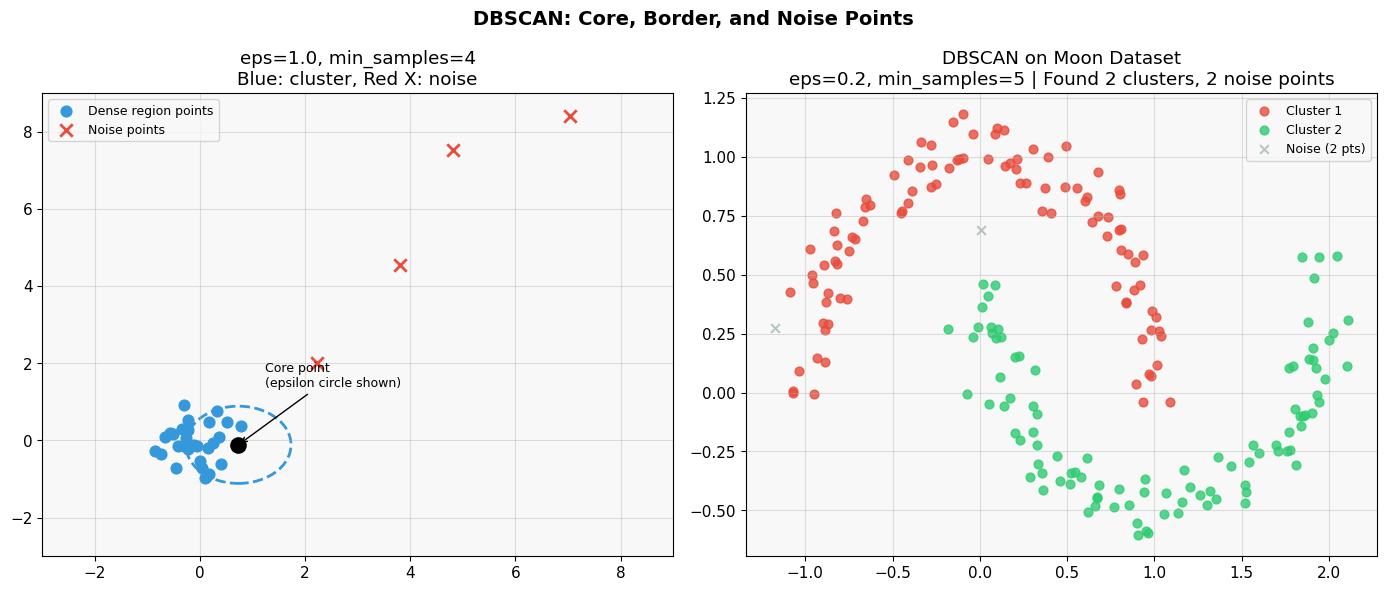

In [ ]:
# Visualizing core points, border points, and noise in DBSCAN
np.random.seed(42)
X_concept = np.vstack([
    np.random.randn(30, 2) * 0.5 + [0, 0],
    np.random.randn(4, 2) * 2.5 + [5, 5]
])

db_concept = DBSCAN(eps=1.0, min_samples=4)
labels_concept = db_concept.fit_predict(X_concept)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('DBSCAN: Core, Border, and Noise Points', fontsize=14, fontweight='bold')

# Left: explain the concepts
ax = axes[0]
# Draw a representative core point with its epsilon circle
core_pt = X_concept[10]
circle = plt.Circle(core_pt, 1.0, color='#3498db', fill=False, linewidth=2, linestyle='--')
ax.add_patch(circle)
ax.scatter(X_concept[:30, 0], X_concept[:30, 1], c='#3498db', s=60, zorder=3, label='Dense region points')
ax.scatter(X_concept[30:, 0], X_concept[30:, 1], c='#e74c3c', s=80, marker='x', linewidths=2, zorder=3, label='Noise points')
ax.scatter([core_pt[0]], [core_pt[1]], c='black', s=120, zorder=4)
ax.annotate('Core point\n(epsilon circle shown)', xy=core_pt, xytext=core_pt + [0.5, 1.5],
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)
ax.set_title(f'eps=1.0, min_samples=4\nBlue: cluster, Red X: noise')
ax.legend(fontsize=9)
ax.set_xlim(-3, 9)
ax.set_ylim(-3, 9)

# Right: effect of different eps values
X_moons, y_moons = make_moons(n_samples=200, noise=0.08, random_state=42)
db_moon = DBSCAN(eps=0.2, min_samples=5)
labels_moon = db_moon.fit_predict(X_moons)
n_clusters = len(set(labels_moon)) - (1 if -1 in labels_moon else 0)
n_noise = list(labels_moon).count(-1)

unique_labels = set(labels_moon)
color_map = {0: '#e74c3c', 1: '#2ecc71', -1: '#aab7b8'}
for label in unique_labels:
    mask = labels_moon == label
    c = color_map.get(label, '#9b59b6')
    marker = 'x' if label == -1 else 'o'
    lbl = f'Noise ({n_noise} pts)' if label == -1 else f'Cluster {label+1}'
    axes[1].scatter(X_moons[mask, 0], X_moons[mask, 1], c=c, s=40, marker=marker, label=lbl, alpha=0.8)
axes[1].set_title(f'DBSCAN on Moon Dataset\neps=0.2, min_samples=5 | Found {n_clusters} clusters, {n_noise} noise points')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

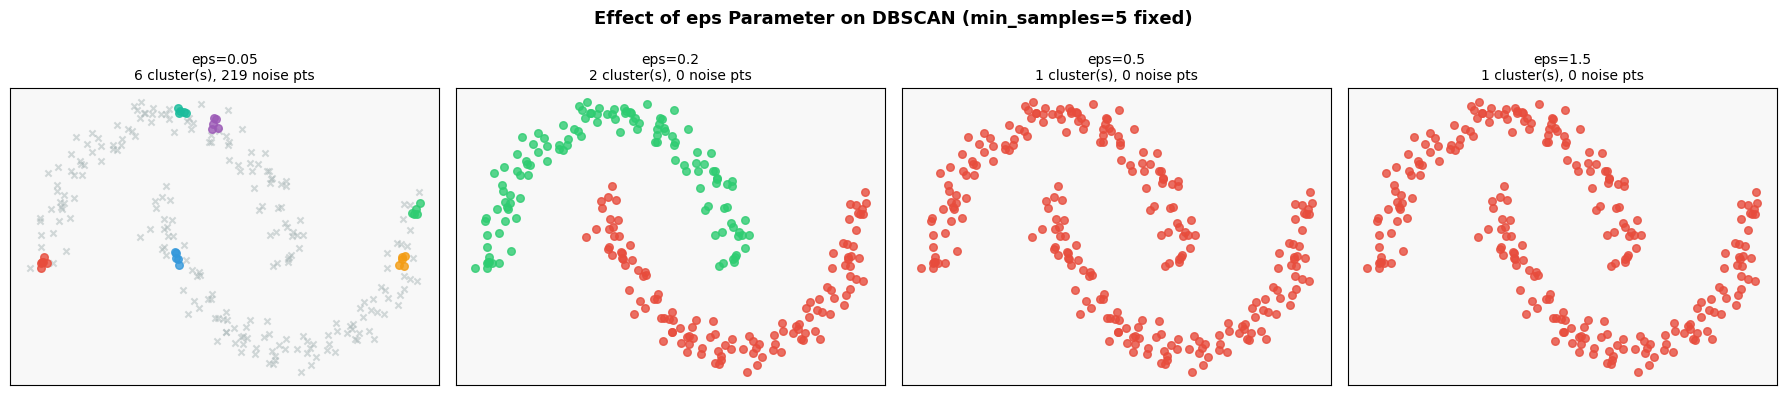

Too small eps: most points are noise (underfitting).
Too large eps: everything merged into one cluster (overfitting).
Middle ground eps: finds the true structure.


In [ ]:
# Effect of eps parameter on DBSCAN results
X_db, _ = make_moons(n_samples=250, noise=0.07, random_state=42)

eps_values = [0.05, 0.2, 0.5, 1.5]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Effect of eps Parameter on DBSCAN (min_samples=5 fixed)', fontsize=13, fontweight='bold')

for idx, eps in enumerate(eps_values):
    db = DBSCAN(eps=eps, min_samples=5)
    lbl = db.fit_predict(X_db)
    n_cl = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_no = list(lbl).count(-1)

    unique = sorted(set(lbl))
    palette = ['#aab7b8'] + ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']
    for j, u in enumerate(unique):
        mask = lbl == u
        if u == -1:
            axes[idx].scatter(X_db[mask, 0], X_db[mask, 1], c='#aab7b8', s=20, marker='x', alpha=0.5)
        else:
            ci = (u % 6) + 1
            axes[idx].scatter(X_db[mask, 0], X_db[mask, 1], c=palette[ci], s=30, alpha=0.8)

    axes[idx].set_title(f'eps={eps}\n{n_cl} cluster(s), {n_no} noise pts', fontsize=10)
    axes[idx].set_xticks([])
    axes[idx].set_yticks([])

plt.tight_layout()
plt.show()
print('Too small eps: most points are noise (underfitting).')
print('Too large eps: everything merged into one cluster (overfitting).')
print('Middle ground eps: finds the true structure.')

---

## Section 5: Principal Component Analysis (PCA)

### The Problem of High Dimensions

Real-world data often has hundreds or thousands of features. Working in such high-dimensional spaces is problematic for several reasons:

- Many machine learning algorithms become slow or ineffective with many features (the curse of dimensionality)
- It is impossible to visualize data beyond 3 dimensions
- Many features are correlated, meaning they carry redundant information
- High dimensions often contain a lot of noise

PCA addresses these problems by finding a new, lower-dimensional coordinate system that captures as much of the variance (information) in the data as possible.

### The Core Idea

Imagine shining a light on a 3D object and looking at its shadow on a wall. The shadow is a 2D projection of the 3D object. If you choose the right angle of light, you can see almost everything important about the object's shape in that shadow.

PCA is doing exactly this: it finds the directions in the original feature space along which the data varies the most, and it projects the data onto those directions. These directions are called **principal components**.

### The Mathematics

**Step 1: Center the data.** Subtract the mean of each feature so the data is centered at the origin.

**Step 2: Compute the covariance matrix.** The covariance matrix $\Sigma$ captures how features vary together:
$$\Sigma = \frac{1}{n-1} X^T X$$

**Step 3: Eigendecomposition.** Decompose the covariance matrix into eigenvectors and eigenvalues:
$$\Sigma v = \lambda v$$

Each eigenvector $v$ is a principal component direction. Its corresponding eigenvalue $\lambda$ tells you how much variance lies along that direction.

**Step 4: Sort by eigenvalue.** The eigenvector with the largest eigenvalue captures the most variance. Sort all eigenvectors by their eigenvalues in descending order.

**Step 5: Project.** Choose the top $d$ eigenvectors. Project the data onto these $d$ directions to get the reduced representation.

### Explained Variance

The proportion of variance explained by the $k$-th principal component is:
$$\frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}$$

We typically plot the cumulative explained variance to decide how many components to keep.

### What PCA Assumes

PCA assumes that the most important directions are those with the highest variance. It also assumes that the relationships between features are linear. For nonlinear structures, techniques like t-SNE or UMAP are more appropriate.

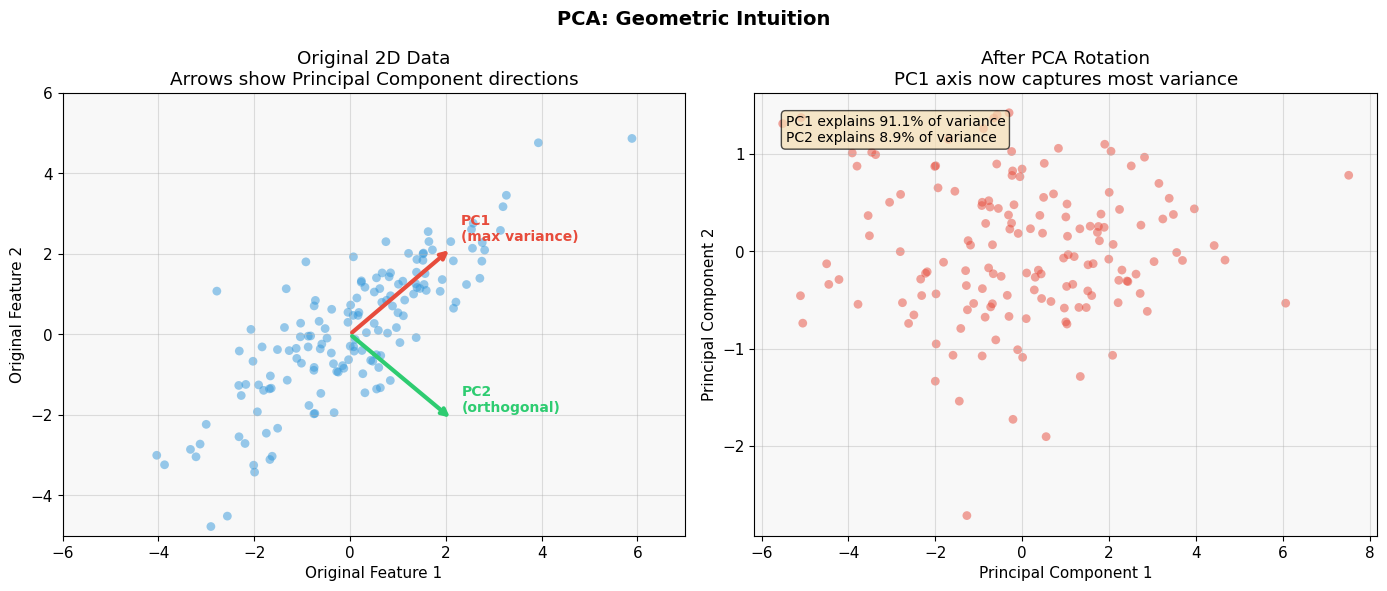

In [ ]:
# PCA: geometric intuition in 2D
np.random.seed(42)
mean = [0, 0]
cov = [[3, 2.5], [2.5, 3]]
X_pca_2d = np.random.multivariate_normal(mean, cov, 150)

pca_2d = PCA(n_components=2)
pca_2d.fit(X_pca_2d)
pc1 = pca_2d.components_[0]
pc2 = pca_2d.components_[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PCA: Geometric Intuition', fontsize=14, fontweight='bold')

# Original data with principal component directions
axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.5, c='#3498db', s=40, edgecolors='none')
scale = 3
axes[0].annotate('', xy=pc1 * scale, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=3))
axes[0].annotate('', xy=pc2 * scale, xytext=[0, 0],
                arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=3))
axes[0].text(*(pc1 * scale + 0.2), 'PC1\n(max variance)', color='#e74c3c', fontsize=10, fontweight='bold')
axes[0].text(*(pc2 * scale + 0.2), 'PC2\n(orthogonal)', color='#2ecc71', fontsize=10, fontweight='bold')
axes[0].set_title('Original 2D Data\nArrows show Principal Component directions')
axes[0].set_xlim(-6, 7)
axes[0].set_ylim(-5, 6)
axes[0].set_xlabel('Original Feature 1')
axes[0].set_ylabel('Original Feature 2')

# After projection to 1D
X_proj = pca_2d.transform(X_pca_2d)
axes[1].scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.5, c='#e74c3c', s=40, edgecolors='none')
axes[1].set_title('After PCA Rotation\nPC1 axis now captures most variance')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
ev = pca_2d.explained_variance_ratio_
axes[1].text(0.05, 0.95, f'PC1 explains {ev[0]*100:.1f}% of variance\nPC2 explains {ev[1]*100:.1f}% of variance',
             transform=axes[1].transAxes, verticalalignment='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

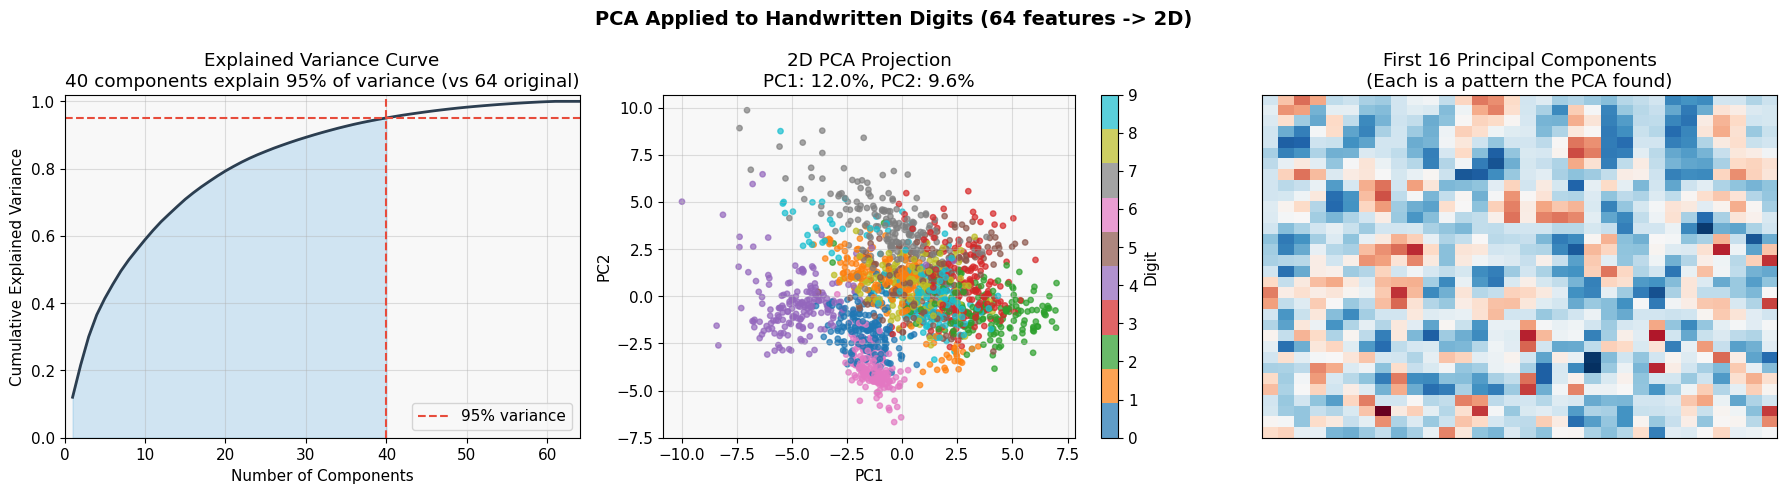

Original data: 64 features
After PCA (95% variance): 40 features
Compression ratio: 1.6x


In [ ]:
# PCA on real high-dimensional data: the digits dataset
digits = load_digits()
X_digits = digits.data  # 1797 samples, 64 features (8x8 pixel images)
y_digits = digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_digits)

# Compute explained variance for all components
pca_full = PCA().fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PCA Applied to Handwritten Digits (64 features -> 2D)', fontsize=14, fontweight='bold')

# Explained variance curve
axes[0].plot(range(1, len(cumulative_variance)+1), cumulative_variance, '-', color='#2c3e50', linewidth=2)
axes[0].axhline(y=0.95, color='#e74c3c', linestyle='--', label='95% variance')
axes[0].axvline(x=n_95, color='#e74c3c', linestyle='--')
axes[0].fill_between(range(1, n_95+1), 0, cumulative_variance[:n_95], alpha=0.2, color='#3498db')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title(f'Explained Variance Curve\n{n_95} components explain 95% of variance (vs 64 original)')
axes[0].legend()
axes[0].set_xlim(0, 64)
axes[0].set_ylim(0, 1.02)

# 2D projection
pca_2 = PCA(n_components=2)
X_2d = pca_2.fit_transform(X_scaled)
scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y_digits, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, ax=axes[1], label='Digit')
axes[1].set_title(f'2D PCA Projection\nPC1: {pca_2.explained_variance_ratio_[0]*100:.1f}%, PC2: {pca_2.explained_variance_ratio_[1]*100:.1f}%')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Show what the principal components look like as images
pca_show = PCA(n_components=16).fit(X_scaled)
axes[2].set_title('First 16 Principal Components\n(Each is a pattern the PCA found)')
grid_img = np.zeros((4 * 8, 4 * 8))
for i in range(16):
    r, c = divmod(i, 4)
    component_img = pca_show.components_[i].reshape(8, 8)
    grid_img[r*8:(r+1)*8, c*8:(c+1)*8] = component_img
axes[2].imshow(grid_img, cmap='RdBu_r', aspect='auto')
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

print(f'Original data: {X_digits.shape[1]} features')
print(f'After PCA (95% variance): {n_95} features')
print(f'Compression ratio: {X_digits.shape[1]/n_95:.1f}x')

---

## Section 6: t-SNE (t-Distributed Stochastic Neighbor Embedding)

### Why PCA Is Not Always Enough

PCA is a linear method. It can only find structure that appears as directions of maximum variance in the original feature space. Many real datasets have nonlinear structure, meaning the interesting patterns live on curved surfaces or manifolds embedded in high-dimensional space.

For example, if you imagine data points arranged on a spiral in 3D space, PCA would project this onto a flat plane and destroy the spiral structure. t-SNE can preserve it.

### The Core Idea

t-SNE is a dimensionality reduction technique specifically designed for visualization. It works by preserving local relationships: points that are close to each other in high-dimensional space should remain close in the 2D or 3D visualization.

The algorithm does this in two phases:

**Phase 1 (High-dimensional probabilities):** For every pair of points, compute a probability that they would be "neighbors" in the original space. Points that are close get high probability; distant points get near-zero probability. These probabilities are computed using a Gaussian distribution.

$$p_{j|i} = \frac{\exp(-\|x_i - x_j\|^2 / 2\sigma_i^2)}{\sum_{k \neq i} \exp(-\|x_i - x_k\|^2 / 2\sigma_i^2)}$$

**Phase 2 (Low-dimensional probabilities):** Place the points randomly in 2D space. Compute a similar probability for the 2D positions, but using a Student's t-distribution instead of a Gaussian:

$$q_{ij} = \frac{(1 + \|y_i - y_j\|^2)^{-1}}{\sum_{k \neq l} (1 + \|y_k - y_l\|^2)^{-1}}$$

**Optimization:** Move the 2D points so that the low-dimensional probabilities $q_{ij}$ match the high-dimensional probabilities $p_{ij}$ as closely as possible. This is measured using KL divergence and minimized by gradient descent.

### The t-Distribution Trick

Using the t-distribution in 2D (instead of Gaussian) is important. The t-distribution has heavier tails than the Gaussian. This means that when two clusters are moderately separated in high dimensions, t-SNE pushes them far apart in 2D, making clusters visually distinct. This is called the "crowding problem" solution.

### Perplexity

The main hyperparameter is perplexity, which roughly controls how many neighbors each point considers when computing its local distribution. Typical values range from 5 to 50. Low perplexity focuses on very local structure; high perplexity considers more global structure.

### Important Caveats

t-SNE is purely for visualization. Distances and cluster sizes in the t-SNE plot are not directly meaningful. Two clusters that look far apart in t-SNE might actually be close in the original space. Always use t-SNE alongside other analysis, not as a standalone conclusion.

Running t-SNE (this may take 30-60 seconds)...


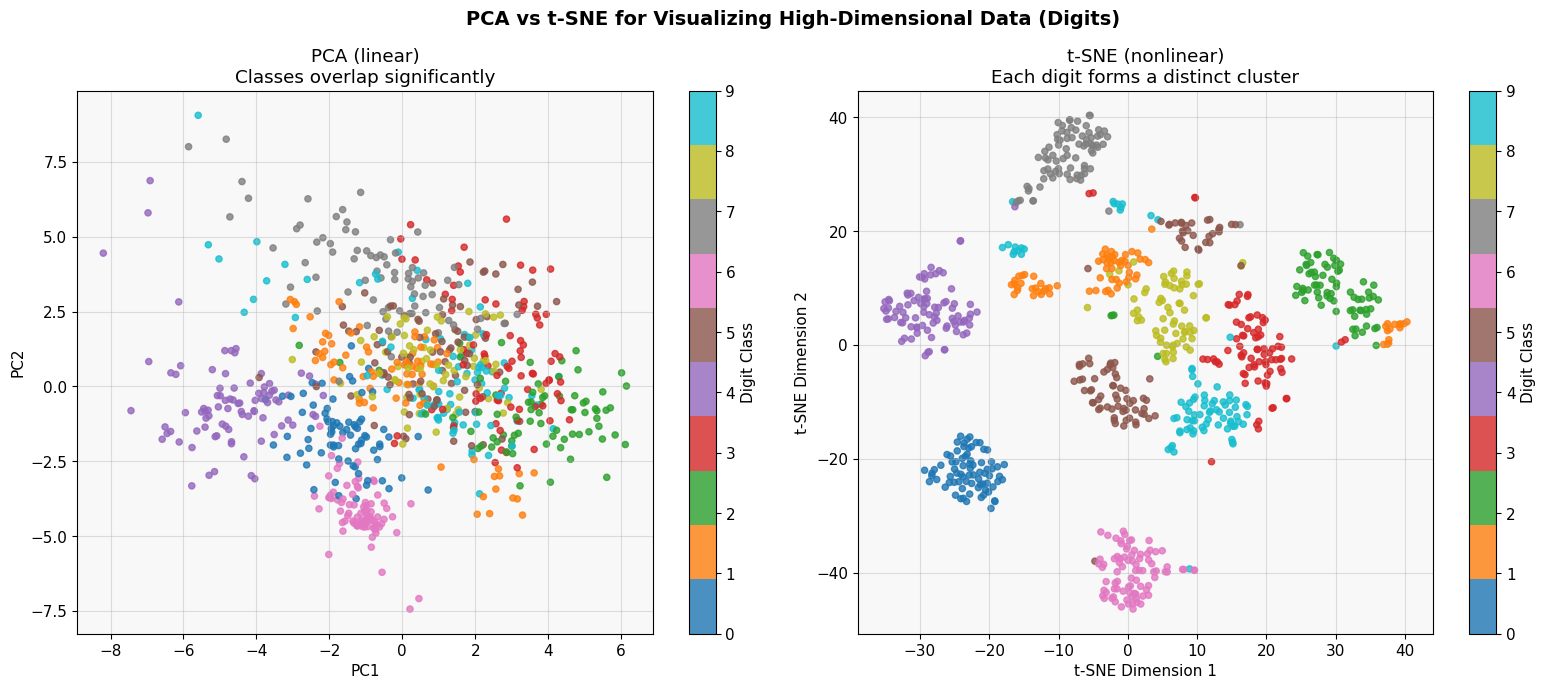

t-SNE produces much more interpretable 2D visualizations for complex datasets.


In [ ]:
# t-SNE vs PCA on digits data
print('Running t-SNE (this may take 30-60 seconds)...')

# Use a subset for speed
np.random.seed(42)
idx = np.random.choice(len(X_digits), 800, replace=False)
X_sub = X_scaled[idx]
y_sub = y_digits[idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_sub)

pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('PCA vs t-SNE for Visualizing High-Dimensional Data (Digits)', fontsize=14, fontweight='bold')

sc1 = axes[0].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1], c=y_sub, cmap='tab10', s=20, alpha=0.8)
plt.colorbar(sc1, ax=axes[0]).set_label('Digit Class')
axes[0].set_title('PCA (linear)\nClasses overlap significantly')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sub, cmap='tab10', s=20, alpha=0.8)
plt.colorbar(sc2, ax=axes[1]).set_label('Digit Class')
axes[1].set_title('t-SNE (nonlinear)\nEach digit forms a distinct cluster')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')

plt.tight_layout()
plt.show()
print('t-SNE produces much more interpretable 2D visualizations for complex datasets.')

Running t-SNE with different perplexity values...


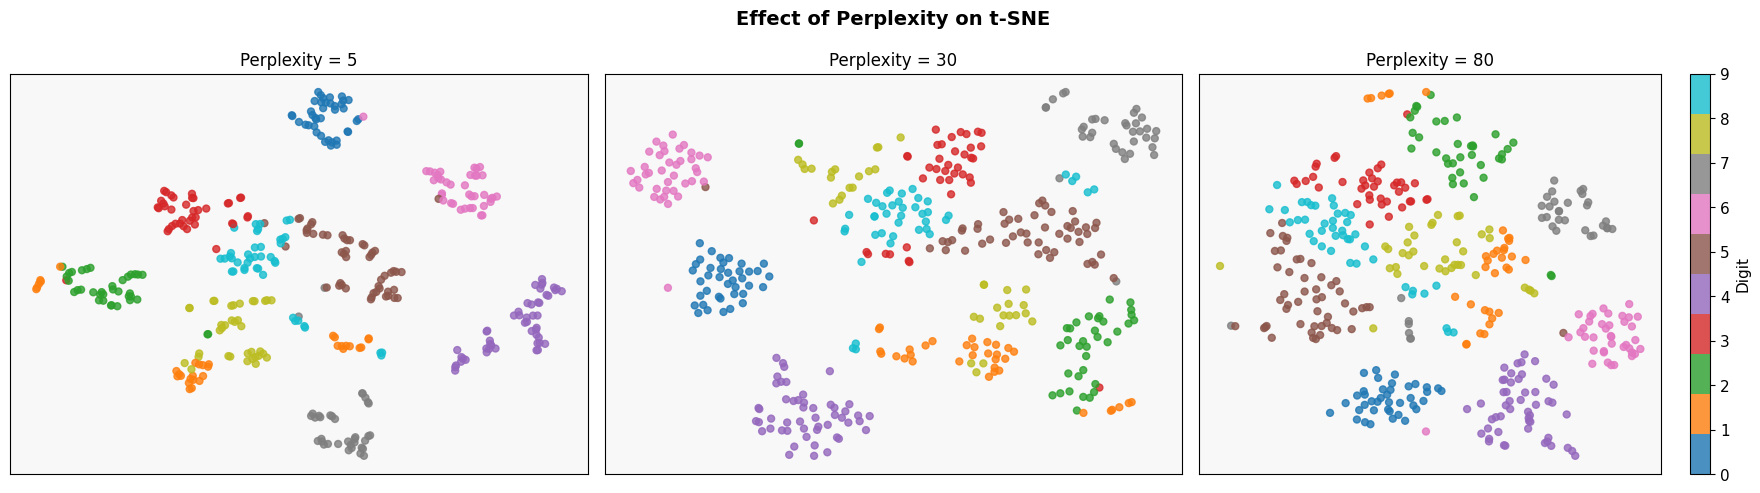

Low perplexity (5): very local structure, many small sub-clusters.
Medium perplexity (30): balanced view, usually the best starting point.
High perplexity (80): more global structure, clusters may merge or blur.


In [ ]:
# Effect of perplexity on t-SNE
print('Running t-SNE with different perplexity values...')
np.random.seed(42)
idx2 = np.random.choice(len(X_digits), 400, replace=False)
X_small = X_scaled[idx2]
y_small = y_digits[idx2]

perplexities = [5, 30, 80]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Effect of Perplexity on t-SNE', fontsize=14, fontweight='bold')

for idx_p, perp in enumerate(perplexities):
    tsne_p = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000)
    X_t = tsne_p.fit_transform(X_small)
    sc = axes[idx_p].scatter(X_t[:, 0], X_t[:, 1], c=y_small, cmap='tab10', s=25, alpha=0.8)
    axes[idx_p].set_title(f'Perplexity = {perp}', fontsize=12)
    axes[idx_p].set_xticks([])
    axes[idx_p].set_yticks([])

plt.colorbar(sc, ax=axes[2], label='Digit')
plt.tight_layout()
plt.show()

print('Low perplexity (5): very local structure, many small sub-clusters.')
print('Medium perplexity (30): balanced view, usually the best starting point.')
print('High perplexity (80): more global structure, clusters may merge or blur.')

---

## Section 7: Gaussian Mixture Models (GMM)

### From Hard to Soft Assignments

In K-Means, every point is assigned to exactly one cluster. This is called a hard assignment. A point on the boundary between two clusters is forced to belong entirely to one of them.

Gaussian Mixture Models (GMM) take a probabilistic approach. Instead of asking "which cluster does this point belong to?", they ask "what is the probability that this point came from each cluster?". This is called a soft assignment.

A point near the boundary might be 60% likely to belong to cluster 1 and 40% likely to belong to cluster 2. This is more realistic when clusters naturally overlap.

### The Model

A GMM assumes that the data was generated by a mixture of $K$ Gaussian distributions. Each Gaussian component $k$ has:

- A mean vector $\mu_k$ (the center of the cluster)
- A covariance matrix $\Sigma_k$ (the shape and orientation of the cluster)
- A mixing coefficient $\pi_k$ (the proportion of data from this component, with $\sum_k \pi_k = 1$)

The probability density of the data under the model is:

$$p(x) = \sum_{k=1}^{K} \pi_k \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

where $\mathcal{N}(x \mid \mu, \Sigma)$ is the multivariate Gaussian density.

### The EM Algorithm

GMMs are fitted using the Expectation-Maximization (EM) algorithm, which alternates between two steps:

**E-step (Expectation):** Compute the responsibility $r_{ik}$, the probability that data point $x_i$ came from component $k$, given the current parameters.

$$r_{ik} = \frac{\pi_k \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}$$

**M-step (Maximization):** Update the parameters using the responsibilities:
$$\mu_k = \frac{\sum_i r_{ik} x_i}{\sum_i r_{ik}}, \quad \Sigma_k = \frac{\sum_i r_{ik}(x_i - \mu_k)(x_i - \mu_k)^T}{\sum_i r_{ik}}, \quad \pi_k = \frac{\sum_i r_{ik}}{n}$$

### GMM vs K-Means

K-Means can be seen as a special case of GMM where all covariance matrices are constrained to be spherical and equal, and assignments are hard rather than soft. GMM is more flexible but also requires more parameters.

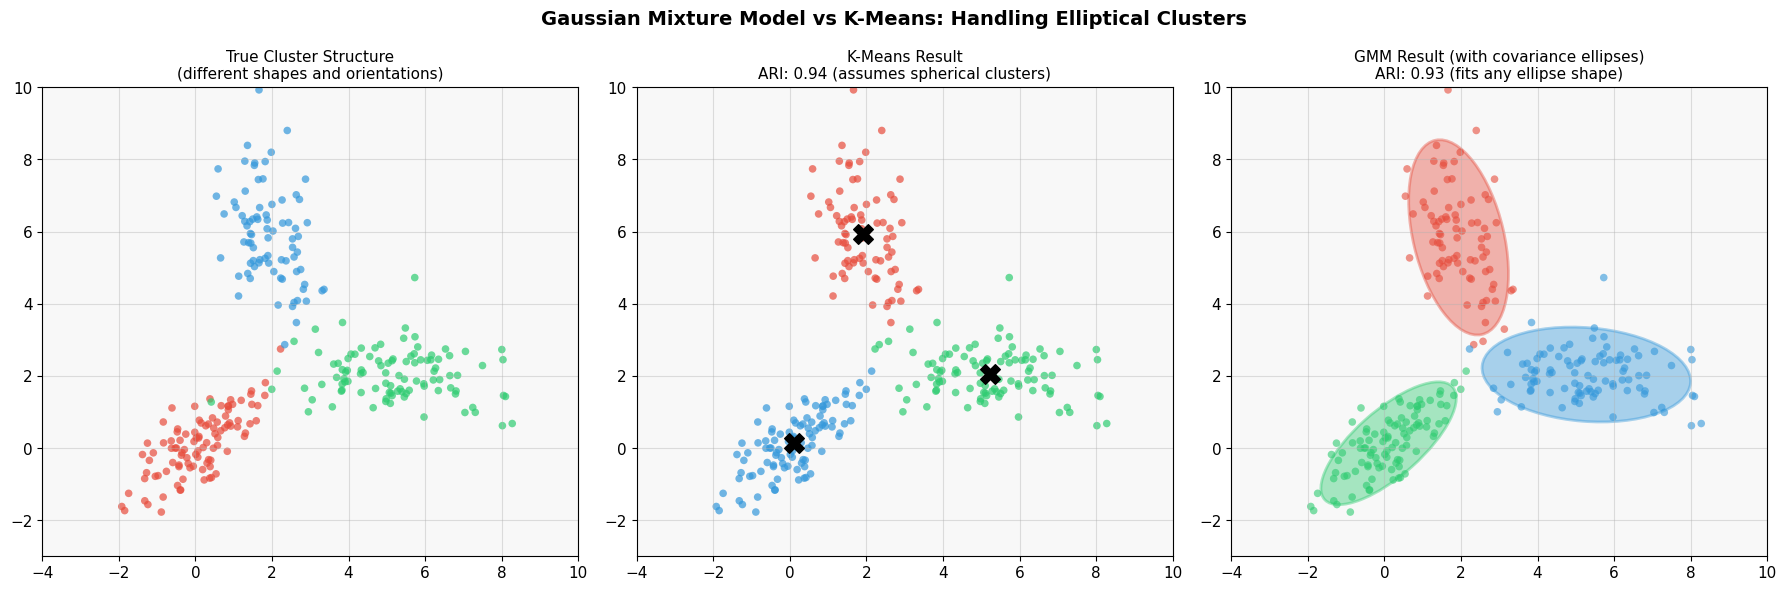

GMM models the shape, orientation, and size of each cluster using the covariance matrix.
K-Means assumes all clusters are spherical, which is often not true.


In [ ]:
# GMM visualization: soft assignments and elliptical clusters
def draw_ellipse(position, covariance, ax, color, alpha=0.3, n_std=2):
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    for alpha_val in [0.15, 0.3]:
        ellip = Ellipse(xy=position, width=width, height=height, angle=angle,
                        facecolor=color, alpha=alpha_val, edgecolor=color, linewidth=2)
        ax.add_patch(ellip)

# Generate data with different shaped clusters
np.random.seed(42)
X1 = np.random.multivariate_normal([0, 0], [[1, 0.8], [0.8, 1]], 100)
X2 = np.random.multivariate_normal([5, 2], [[2, 0], [0, 0.5]], 100)
X3 = np.random.multivariate_normal([2, 6], [[0.5, -0.3], [-0.3, 1.5]], 80)
X_gmm = np.vstack([X1, X2, X3])
y_gmm_true = np.array([0]*100 + [1]*100 + [2]*80)

# Fit GMM and K-Means
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_gmm)
km_compare = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km_compare.fit_predict(X_gmm)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Gaussian Mixture Model vs K-Means: Handling Elliptical Clusters', fontsize=14, fontweight='bold')

gmm_colors = ['#e74c3c', '#2ecc71', '#3498db']

# True data
for k in range(3):
    mask = y_gmm_true == k
    axes[0].scatter(X_gmm[mask, 0], X_gmm[mask, 1], c=gmm_colors[k], s=30, alpha=0.7, edgecolors='none')
axes[0].set_title('True Cluster Structure\n(different shapes and orientations)', fontsize=11)

# K-Means result
for k in range(3):
    mask = km_labels == k
    axes[1].scatter(X_gmm[mask, 0], X_gmm[mask, 1], c=gmm_colors[k], s=30, alpha=0.7, edgecolors='none')
axes[1].scatter(km_compare.cluster_centers_[:, 0], km_compare.cluster_centers_[:, 1],
               c='black', s=200, marker='X', zorder=5)
ari_km = adjusted_rand_score(y_gmm_true, km_labels)
axes[1].set_title(f'K-Means Result\nARI: {ari_km:.2f} (assumes spherical clusters)', fontsize=11)

# GMM result with covariance ellipses
for k in range(3):
    mask = gmm_labels == k
    axes[2].scatter(X_gmm[mask, 0], X_gmm[mask, 1], c=gmm_colors[k], s=30, alpha=0.6, edgecolors='none')
    draw_ellipse(gmm.means_[k], gmm.covariances_[k], axes[2], gmm_colors[k])
ari_gmm = adjusted_rand_score(y_gmm_true, gmm_labels)
axes[2].set_title(f'GMM Result (with covariance ellipses)\nARI: {ari_gmm:.2f} (fits any ellipse shape)', fontsize=11)

for ax in axes:
    ax.set_xlim(-4, 10)
    ax.set_ylim(-3, 10)

plt.tight_layout()
plt.show()

print('GMM models the shape, orientation, and size of each cluster using the covariance matrix.')
print('K-Means assumes all clusters are spherical, which is often not true.')

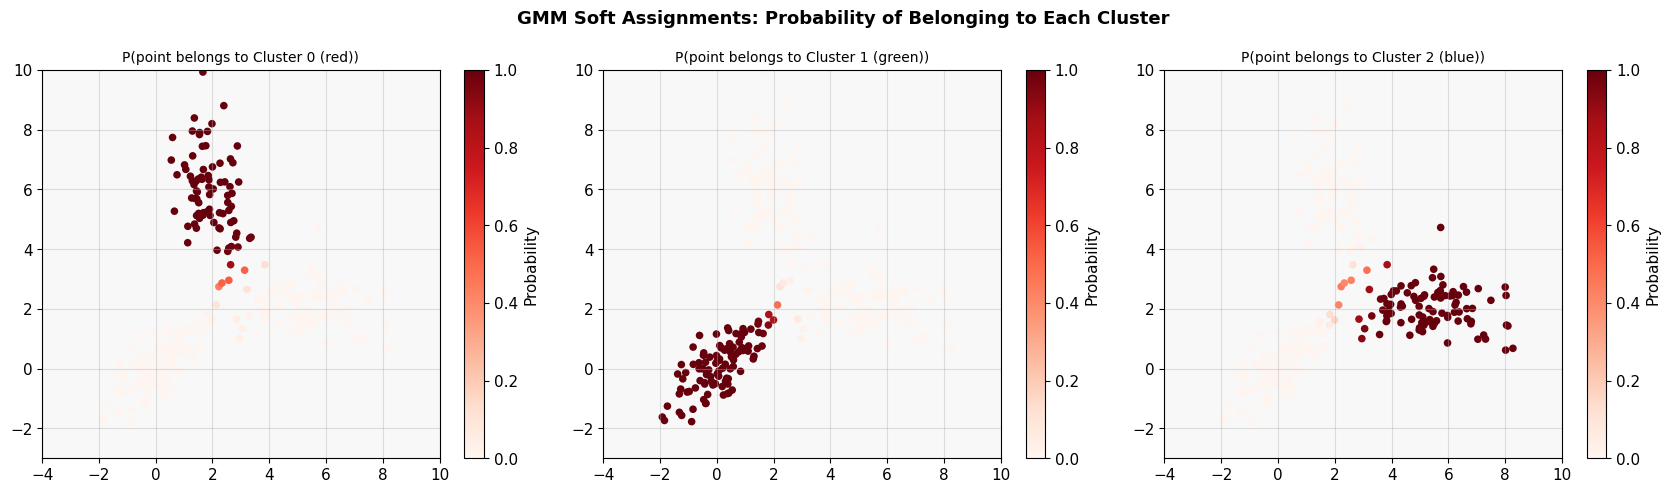

Points with max cluster probability < 0.9 (uncertain/boundary): 11

Sample of uncertain point probabilities:
  Point 37: P(C0)=0.44, P(C1)=0.12, P(C2)=0.44
  Point 55: P(C0)=0.02, P(C1)=0.85, P(C2)=0.14
  Point 118: P(C0)=0.09, P(C1)=0.49, P(C2)=0.42
  Point 125: P(C0)=0.10, P(C1)=0.01, P(C2)=0.88
  Point 127: P(C0)=0.05, P(C1)=0.07, P(C2)=0.88


In [ ]:
# GMM: soft probability assignments
probs = gmm.predict_proba(X_gmm)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('GMM Soft Assignments: Probability of Belonging to Each Cluster', fontsize=13, fontweight='bold')

cluster_names = ['Cluster 0 (red)', 'Cluster 1 (green)', 'Cluster 2 (blue)']
for k in range(3):
    sc = axes[k].scatter(X_gmm[:, 0], X_gmm[:, 1], c=probs[:, k], cmap='Reds',
                          s=30, vmin=0, vmax=1, edgecolors='none')
    plt.colorbar(sc, ax=axes[k], label='Probability')
    axes[k].set_title(f'P(point belongs to {cluster_names[k]})', fontsize=10)
    axes[k].set_xlim(-4, 10)
    axes[k].set_ylim(-3, 10)

plt.tight_layout()
plt.show()

# Show some soft assignments
boundary_mask = np.max(probs, axis=1) < 0.9  # uncertain points
print(f'Points with max cluster probability < 0.9 (uncertain/boundary): {boundary_mask.sum()}')
print('\nSample of uncertain point probabilities:')
for i in np.where(boundary_mask)[0][:5]:
    print(f'  Point {i}: P(C0)={probs[i,0]:.2f}, P(C1)={probs[i,1]:.2f}, P(C2)={probs[i,2]:.2f}')

---

## Section 8: Model Selection for GMM (BIC and AIC)

For GMM, we can use principled statistical criteria to choose the number of components K:

**BIC (Bayesian Information Criterion):** Penalizes model complexity more heavily. Better for finding the "true" number of clusters.

$$\text{BIC} = -2 \log L + k \log n$$

**AIC (Akaike Information Criterion):** Penalizes less strongly. Better for predictive performance.

$$\text{AIC} = -2 \log L + 2k$$

In both, $L$ is the maximized likelihood, $k$ is the number of parameters, and $n$ is the number of data points. Lower is better for both.

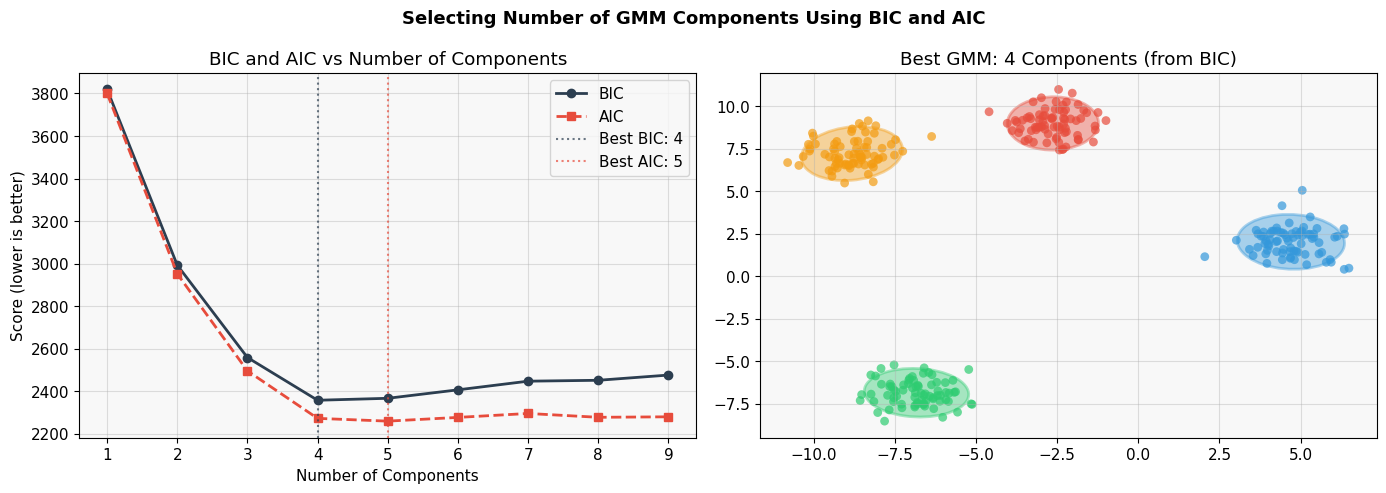

BIC suggests 4 components, AIC suggests 5 components.


In [ ]:
# BIC and AIC for choosing number of GMM components
X_sel, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

n_components_range = range(1, 10)
bic_scores = []
aic_scores = []

for n in n_components_range:
    gmm_sel = GaussianMixture(n_components=n, random_state=42, n_init=3)
    gmm_sel.fit(X_sel)
    bic_scores.append(gmm_sel.bic(X_sel))
    aic_scores.append(gmm_sel.aic(X_sel))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Selecting Number of GMM Components Using BIC and AIC', fontsize=13, fontweight='bold')

best_bic = np.argmin(bic_scores) + 1
best_aic = np.argmin(aic_scores) + 1

axes[0].plot(list(n_components_range), bic_scores, 'o-', color='#2c3e50', label='BIC', linewidth=2)
axes[0].plot(list(n_components_range), aic_scores, 's--', color='#e74c3c', label='AIC', linewidth=2)
axes[0].axvline(x=best_bic, color='#2c3e50', linestyle=':', alpha=0.7, label=f'Best BIC: {best_bic}')
axes[0].axvline(x=best_aic, color='#e74c3c', linestyle=':', alpha=0.7, label=f'Best AIC: {best_aic}')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Score (lower is better)')
axes[0].set_title('BIC and AIC vs Number of Components')
axes[0].legend()

best_gmm = GaussianMixture(n_components=best_bic, random_state=42)
final_labels = best_gmm.fit_predict(X_sel)
for k in range(best_bic):
    mask = final_labels == k
    axes[1].scatter(X_sel[mask, 0], X_sel[mask, 1], c=cluster_colors[k], s=40, alpha=0.7, edgecolors='none')
    draw_ellipse(best_gmm.means_[k], best_gmm.covariances_[k], axes[1], cluster_colors[k])
axes[1].set_title(f'Best GMM: {best_bic} Components (from BIC)')

plt.tight_layout()
plt.show()

print(f'BIC suggests {best_bic} components, AIC suggests {best_aic} components.')

---

## Section 9: Comparing All Clustering Algorithms

By now we have covered four clustering approaches. Each has strengths and weaknesses that depend on the shape and structure of the data. This section puts them side by side on the same datasets so you can see where each algorithm shines and where it fails.

**Summary of when to use each algorithm:**

- **K-Means:** Fast, simple, works well on large datasets with compact spherical clusters. Requires K in advance.
- **Hierarchical:** Does not require K in advance, gives a full picture of cluster relationships via the dendrogram, but is slow for large datasets.
- **DBSCAN:** Can find arbitrary-shaped clusters and identifies outliers. Does not require K. Sensitive to eps and min_samples.
- **GMM:** Probabilistic, handles elliptical clusters, provides soft assignments. Assumes Gaussian structure.

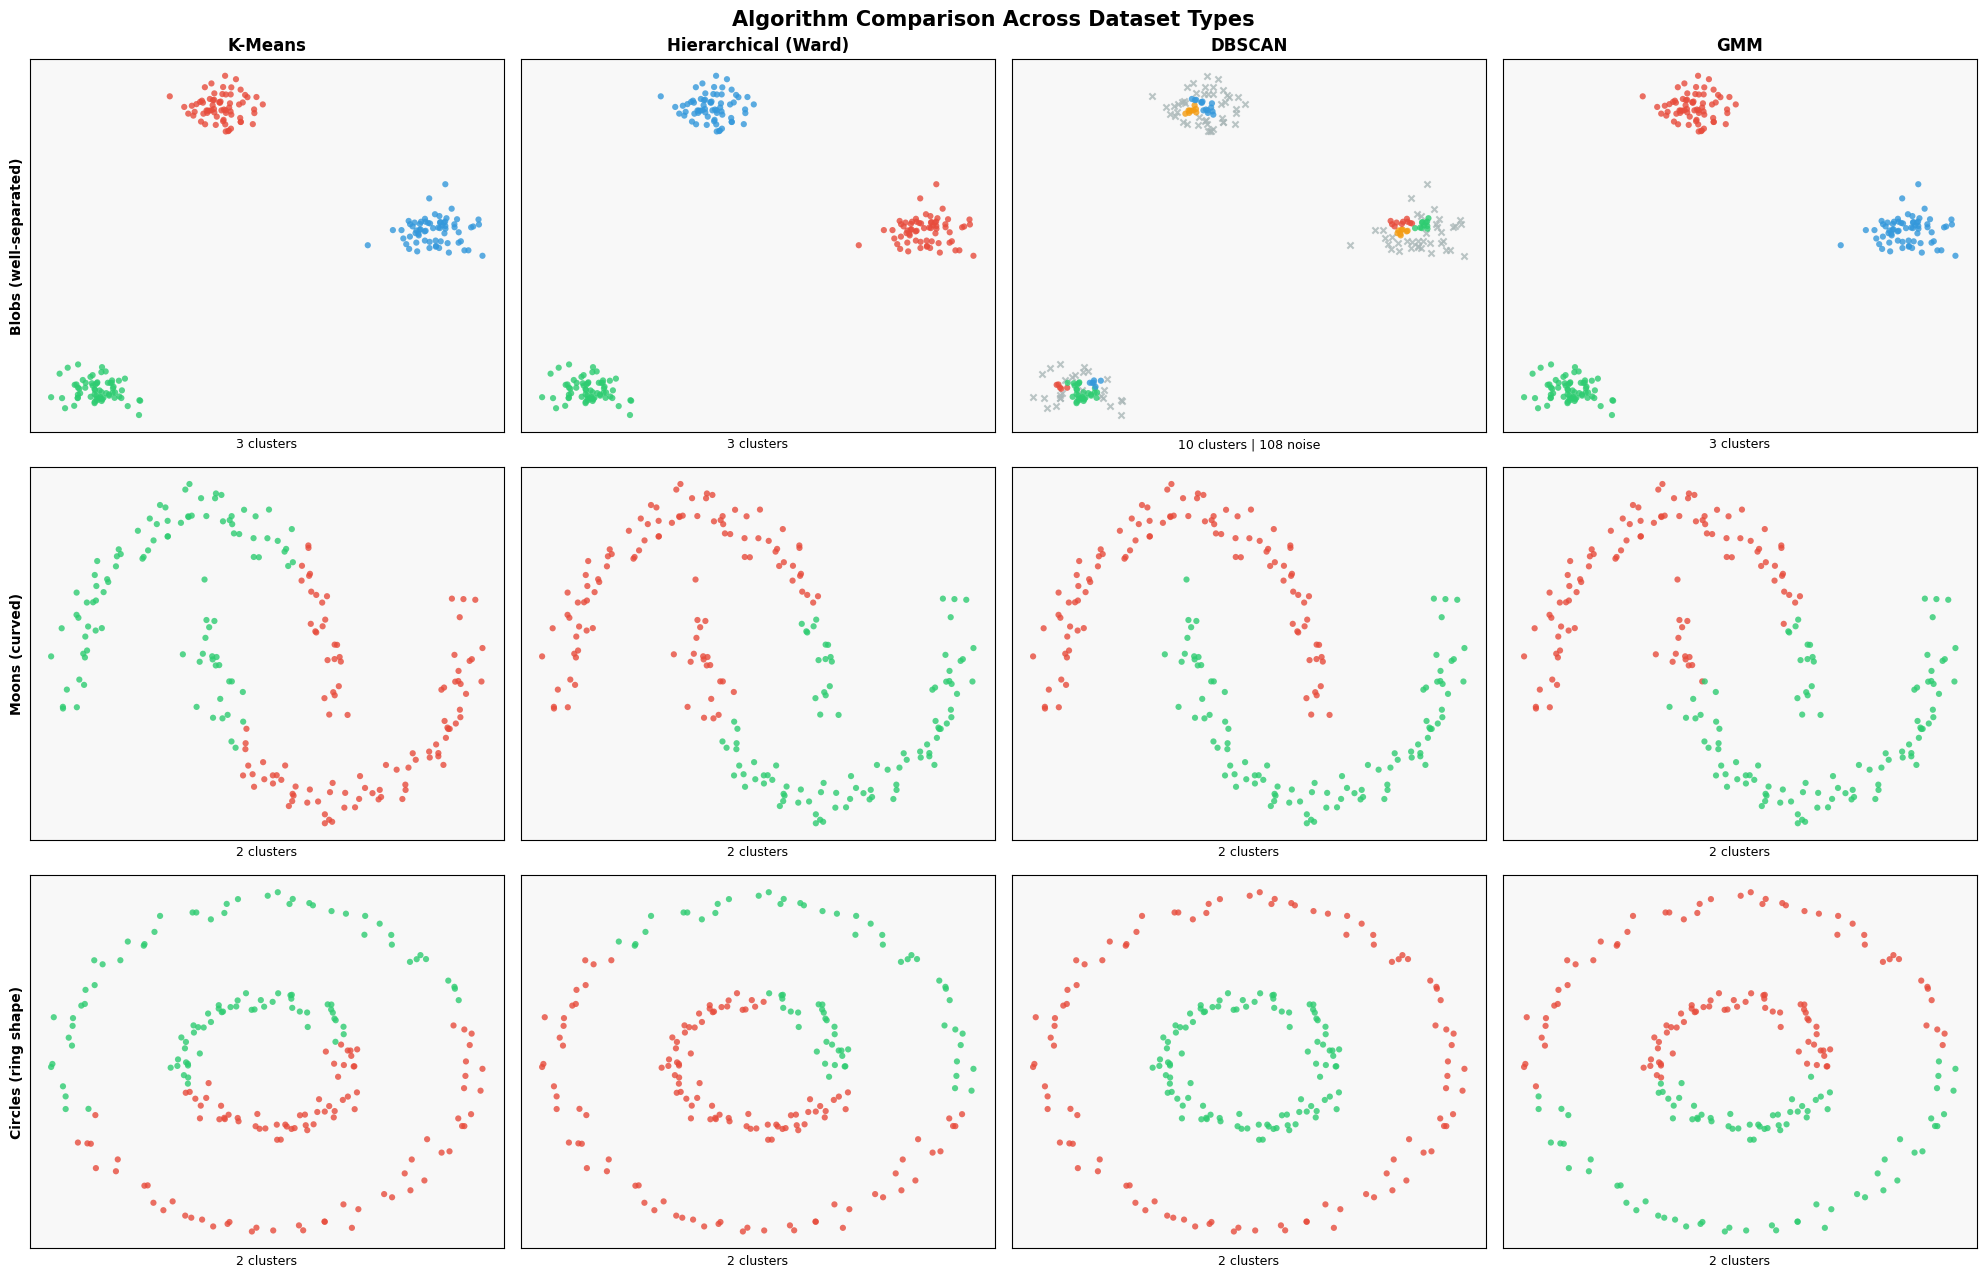

Key observation: DBSCAN handles moons and circles, while K-Means and GMM fail on them.
On well-separated blobs, all algorithms perform similarly.


In [ ]:
# Comprehensive comparison on multiple dataset types
datasets_compare = [
    ('Blobs (well-separated)', *make_blobs(n_samples=200, centers=3, cluster_std=0.7, random_state=42)),
    ('Moons (curved)', *make_moons(n_samples=200, noise=0.07, random_state=42)),
    ('Circles (ring shape)', *make_circles(n_samples=200, noise=0.04, factor=0.4, random_state=42)),
]

algorithms = [
    ('K-Means', lambda X, k: KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)),
    ('Hierarchical (Ward)', lambda X, k: AgglomerativeClustering(n_clusters=k).fit_predict(X)),
    ('DBSCAN', lambda X, k: DBSCAN(eps=0.25, min_samples=5).fit_predict(X)),
    ('GMM', lambda X, k: GaussianMixture(n_components=k, random_state=42).fit_predict(X)),
]

fig, axes = plt.subplots(len(datasets_compare), len(algorithms), figsize=(20, 13))
fig.suptitle('Algorithm Comparison Across Dataset Types', fontsize=15, fontweight='bold')

palette_compare = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6', '#aab7b8']

for row, (ds_name, X_d, y_d) in enumerate(datasets_compare):
    k_true = len(np.unique(y_d))
    for col, (alg_name, alg_func) in enumerate(algorithms):
        ax = axes[row][col]
        labels = alg_func(X_d, k_true)
        unique_labels = sorted(set(labels))
        for i, u in enumerate(unique_labels):
            mask = labels == u
            color = '#aab7b8' if u == -1 else palette_compare[i % 4]
            mk = 'x' if u == -1 else 'o'
            ax.scatter(X_d[mask, 0], X_d[mask, 1], c=color, s=20, marker=mk, alpha=0.8, edgecolors='none')
        n_cl = len(unique_labels) - (1 if -1 in unique_labels else 0)
        n_no = list(labels).count(-1)
        noise_str = f' | {n_no} noise' if n_no > 0 else ''
        if row == 0:
            ax.set_title(alg_name, fontsize=12, fontweight='bold')
        ax.set_xlabel(f'{n_cl} clusters{noise_str}', fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(ds_name, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('Key observation: DBSCAN handles moons and circles, while K-Means and GMM fail on them.')
print('On well-separated blobs, all algorithms perform similarly.')

---

## Section 10: Evaluation Metrics for Clustering

Evaluating clustering is harder than evaluating supervised learning because we do not have ground truth labels in most real applications.

### With Ground Truth Labels (For Research / Benchmarking)

**Adjusted Rand Index (ARI):** Measures the similarity between two clusterings. Ranges from -1 to 1. ARI = 1 means perfect agreement. ARI = 0 means random clustering. Adjusted for chance.

**Normalized Mutual Information (NMI):** Measures how much information the predicted clustering shares with the true labels. Ranges from 0 to 1.

### Without Ground Truth Labels (For Real Applications)

**Silhouette Score:** For each point, measures how similar it is to its own cluster compared to the nearest neighboring cluster. Ranges from -1 to 1. Higher is better. A score near 1 means the point is well-matched to its cluster. Near 0 means it is on the boundary. Negative means it may be in the wrong cluster.

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where $a(i)$ is the mean intra-cluster distance and $b(i)$ is the mean nearest-cluster distance.

**Davies-Bouldin Index:** Measures the ratio of within-cluster scatter to between-cluster separation. Lower is better.

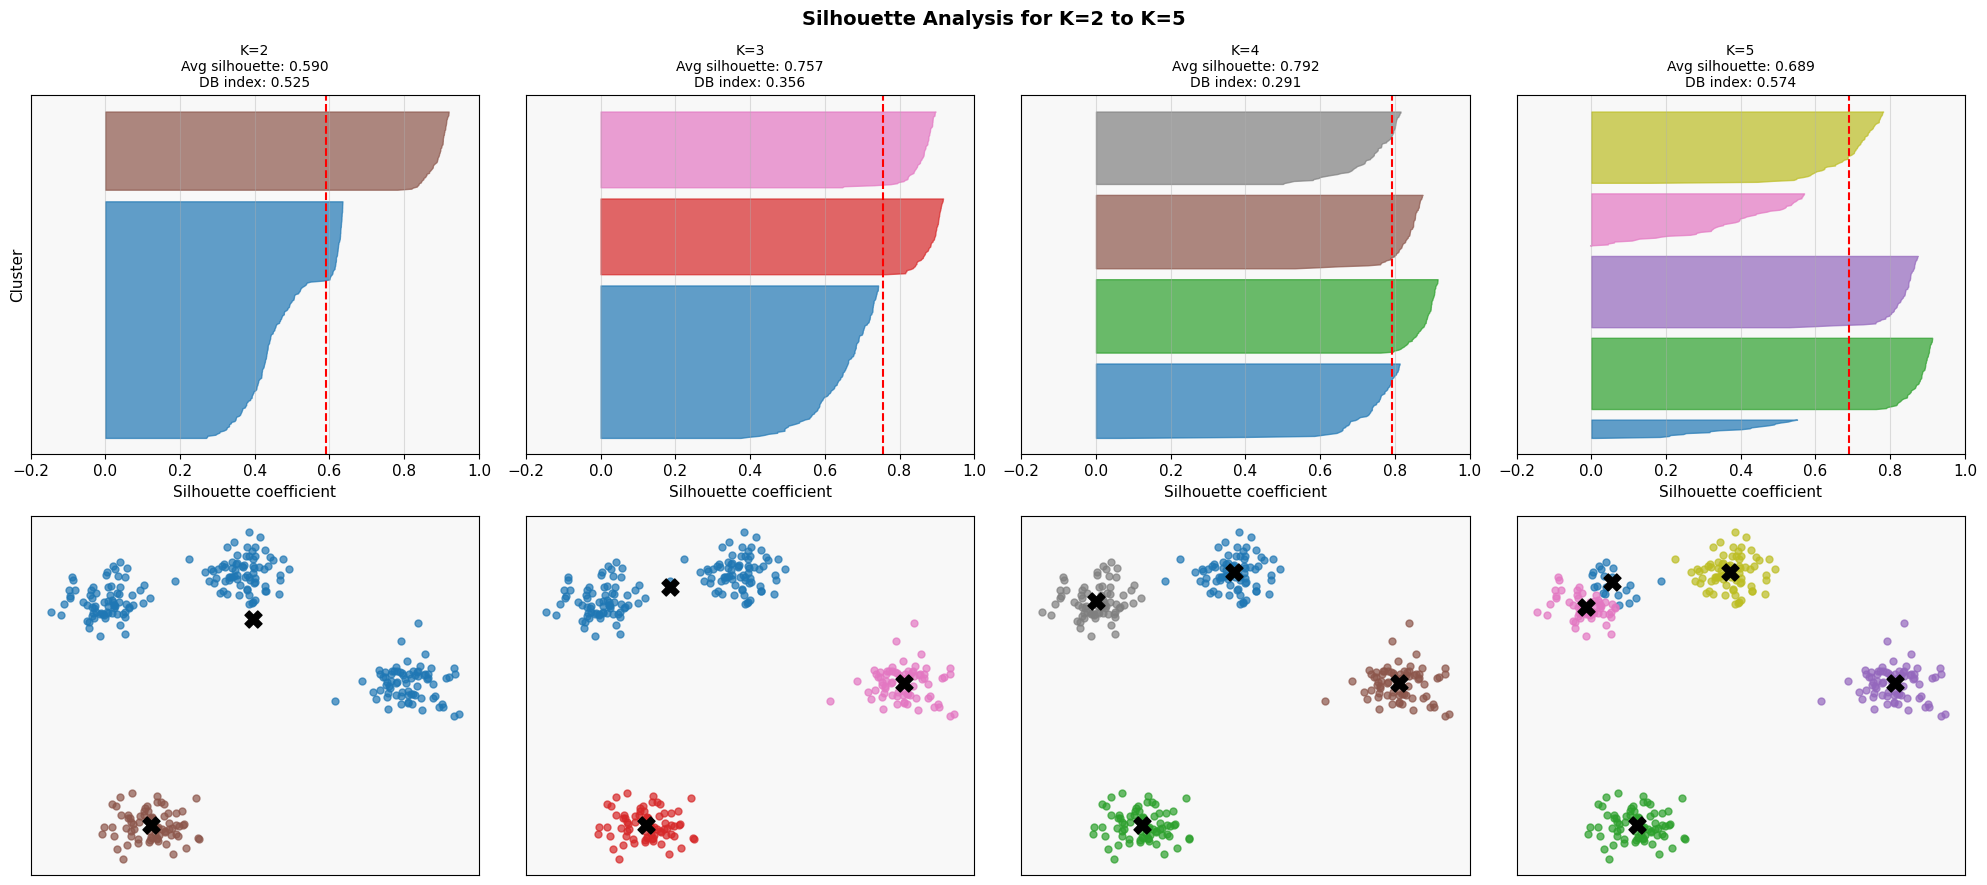

Wide silhouette bars = well-defined cluster. Narrow or below-zero = poor separation.
K=4 should show the best average silhouette score since the data was generated with 4 centers.


In [ ]:
# Silhouette analysis in detail
from sklearn.metrics import davies_bouldin_score

X_eval, y_eval = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Silhouette Analysis for K=2 to K=5', fontsize=14, fontweight='bold')

from matplotlib.cm import get_cmap

for col, k in enumerate(range(2, 6)):
    km_eval = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_eval = km_eval.fit_predict(X_eval)
    silhouette_avg = silhouette_score(X_eval, labels_eval)
    db = davies_bouldin_score(X_eval, labels_eval)

    from sklearn.metrics import silhouette_samples
    sample_silhouette_values = silhouette_samples(X_eval, labels_eval)

    ax_sil = axes[0][col]
    y_lower = 10
    for ki in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[labels_eval == ki]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = plt.cm.tab10(ki / k)
        ax_sil.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                              facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper + 10

    ax_sil.axvline(x=silhouette_avg, color='red', linestyle='--', linewidth=1.5)
    ax_sil.set_title(f'K={k}\nAvg silhouette: {silhouette_avg:.3f}\nDB index: {db:.3f}', fontsize=10)
    ax_sil.set_xlabel('Silhouette coefficient')
    ax_sil.set_yticks([])
    ax_sil.set_xlim(-0.2, 1.0)
    if col == 0:
        ax_sil.set_ylabel('Cluster')

    ax_sc = axes[1][col]
    for ki in range(k):
        mask = labels_eval == ki
        ax_sc.scatter(X_eval[mask, 0], X_eval[mask, 1], c=[plt.cm.tab10(ki/k)], s=25, alpha=0.7)
    ax_sc.scatter(km_eval.cluster_centers_[:, 0], km_eval.cluster_centers_[:, 1],
                  c='black', s=150, marker='X', zorder=5)
    ax_sc.set_xticks([])
    ax_sc.set_yticks([])

plt.tight_layout()
plt.show()
print('Wide silhouette bars = well-defined cluster. Narrow or below-zero = poor separation.')
print('K=4 should show the best average silhouette score since the data was generated with 4 centers.')

---

## Section 11: A Complete End-to-End Example

Now we bring everything together. We will take a real-world style dataset, apply preprocessing, try multiple algorithms, visualize results, and evaluate them. This is the kind of workflow you would use in practice.

In [ ]:
# End-to-end pipeline: customer segmentation simulation
np.random.seed(42)

# Simulate customer data (annual_spend, visit_frequency, avg_purchase_size, loyalty_score)
n_customers = 400
segment_data = []
segment_labels_true = []

# Segment 0: High spend, frequent visitors
seg0 = np.random.multivariate_normal([80, 20, 4.0, 8], [[100, 20, 0.5, 1], [20, 25, 0.3, 0.5],
                                                          [0.5, 0.3, 0.3, 0.1], [1, 0.5, 0.1, 1.5]], 100)
# Segment 1: Low spend, rare visitors
seg1 = np.random.multivariate_normal([20, 3, 1.5, 3], [[50, 3, 0.2, 0.5], [3, 5, 0.1, 0.2],
                                                         [0.2, 0.1, 0.2, 0.05], [0.5, 0.2, 0.05, 0.8]], 120)
# Segment 2: Medium spend, medium frequency
seg2 = np.random.multivariate_normal([50, 10, 2.5, 5], [[80, 10, 0.4, 0.8], [10, 12, 0.2, 0.3],
                                                          [0.4, 0.2, 0.25, 0.1], [0.8, 0.3, 0.1, 1.2]], 100)
# Segment 3: High purchase size, low frequency
seg3 = np.random.multivariate_normal([60, 4, 8.0, 6], [[90, 5, 1.0, 1], [5, 6, 0.4, 0.2],
                                                         [1.0, 0.4, 1.5, 0.2], [1, 0.2, 0.2, 1]], 80)

X_customers = np.vstack([seg0, seg1, seg2, seg3])
y_customers_true = np.array([0]*100 + [1]*120 + [2]*100 + [3]*80)

feature_names = ['Annual Spend ($00)', 'Visit Frequency', 'Avg Purchase Size', 'Loyalty Score']
df_customers = pd.DataFrame(X_customers, columns=feature_names)

print('Customer Dataset Shape:', df_customers.shape)
print('\nDataset Statistics:')
print(df_customers.describe().round(2))

Customer Dataset Shape: (400, 4)

Dataset Statistics:
       Annual Spend ($00)  Visit Frequency  Avg Purchase Size  Loyalty Score
count              400.00           400.00             400.00         400.00
mean                50.14             9.01               3.64           5.30
std                 23.87             7.57               2.46           2.16
min                  5.69            -2.26               0.38           0.24
25%                 26.75             3.23               1.79           3.67
50%                 51.82             6.25               2.87           5.13
75%                 70.08            14.04               4.50           6.79
max                100.33            28.67              10.88          12.01


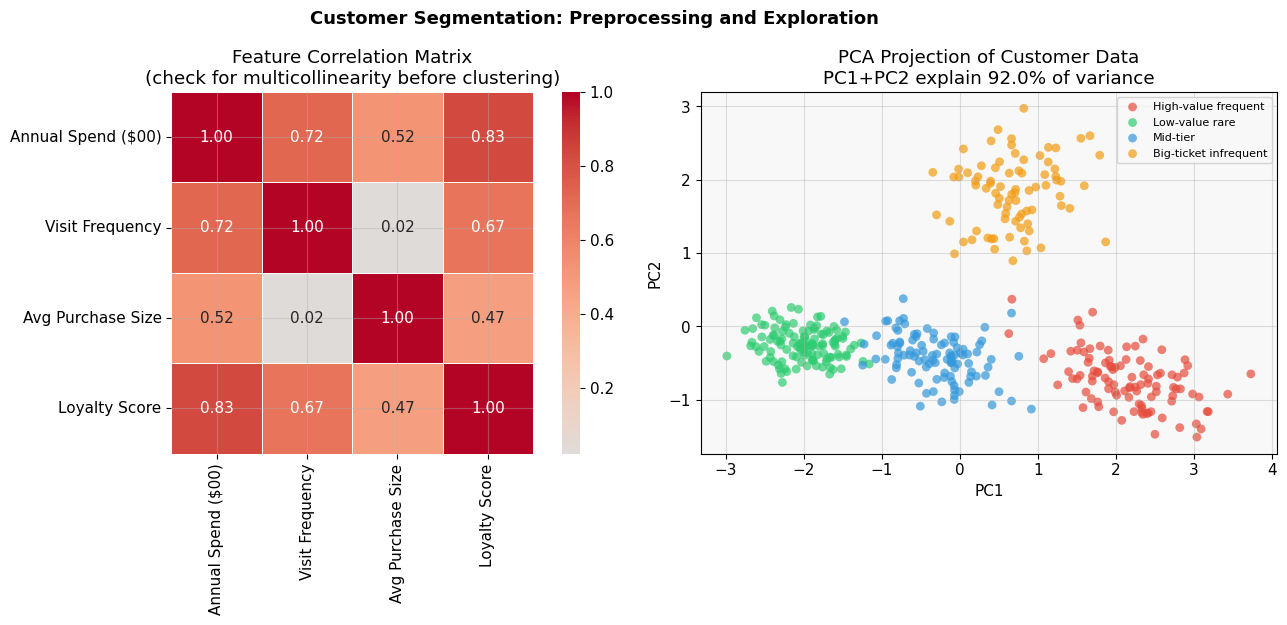

In [ ]:
# Step 1: Preprocessing and PCA visualization
scaler_cust = StandardScaler()
X_cust_scaled = scaler_cust.fit_transform(X_customers)

pca_cust = PCA(n_components=2)
X_cust_2d = pca_cust.fit_transform(X_cust_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Customer Segmentation: Preprocessing and Exploration', fontsize=13, fontweight='bold')

# Pair plot style heatmap
corr_matrix = df_customers.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Feature Correlation Matrix\n(check for multicollinearity before clustering)')

# PCA 2D view
cust_colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
cust_labels_names = ['High-value frequent', 'Low-value rare', 'Mid-tier', 'Big-ticket infrequent']
for k in range(4):
    mask = y_customers_true == k
    axes[1].scatter(X_cust_2d[mask, 0], X_cust_2d[mask, 1], c=cust_colors[k],
                    s=40, alpha=0.7, label=cust_labels_names[k], edgecolors='none')
axes[1].set_title(f'PCA Projection of Customer Data\nPC1+PC2 explain {sum(pca_cust.explained_variance_ratio_)*100:.1f}% of variance')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

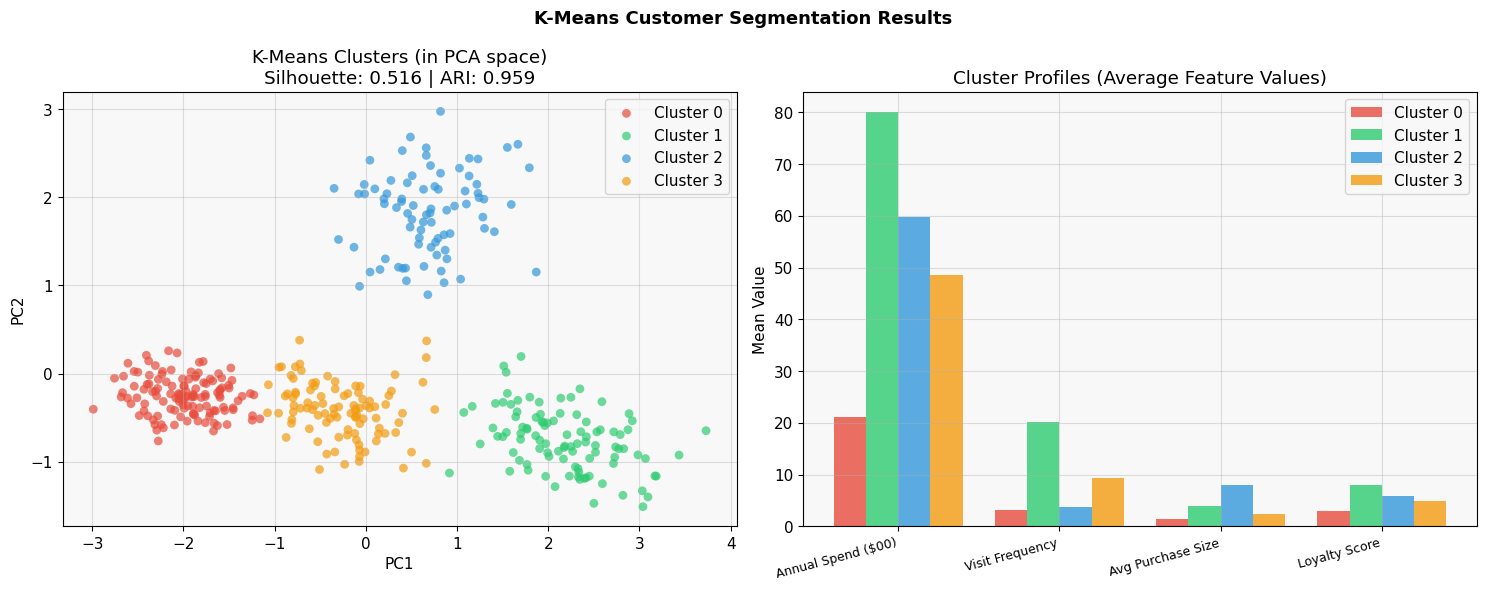

Cluster Profiles:
         Annual Spend ($00)  Visit Frequency  Avg Purchase Size  Loyalty Score
Cluster                                                                       
0                      21.2              3.1                1.5            3.0
1                      80.0             20.1                4.0            8.0
2                      59.7              3.8                7.9            6.0
3                      48.5              9.4                2.5            4.9


In [ ]:
# Step 2: Apply K-Means and evaluate
km_cust = KMeans(n_clusters=4, random_state=42, n_init=10)
km_cust_labels = km_cust.fit_predict(X_cust_scaled)

sil = silhouette_score(X_cust_scaled, km_cust_labels)
ari = adjusted_rand_score(y_customers_true, km_cust_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('K-Means Customer Segmentation Results', fontsize=13, fontweight='bold')

# Scatter plot
for k in range(4):
    mask = km_cust_labels == k
    axes[0].scatter(X_cust_2d[mask, 0], X_cust_2d[mask, 1], c=cust_colors[k], s=40, alpha=0.7,
                    label=f'Cluster {k}', edgecolors='none')
axes[0].set_title(f'K-Means Clusters (in PCA space)\nSilhouette: {sil:.3f} | ARI: {ari:.3f}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Cluster profiles (radar/bar)
df_clustered = df_customers.copy()
df_clustered['Cluster'] = km_cust_labels
cluster_profiles = df_clustered.groupby('Cluster')[feature_names].mean()

x = np.arange(len(feature_names))
width = 0.2
for k in range(4):
    axes[1].bar(x + k*width, cluster_profiles.iloc[k], width, label=f'Cluster {k}', color=cust_colors[k], alpha=0.8)
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(feature_names, rotation=15, ha='right', fontsize=9)
axes[1].set_title('Cluster Profiles (Average Feature Values)')
axes[1].set_ylabel('Mean Value')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Cluster Profiles:')
print(cluster_profiles.round(1).to_string())

---

## Section 12: Summary and Algorithm Decision Guide

This section serves as a reference card for choosing the right algorithm.

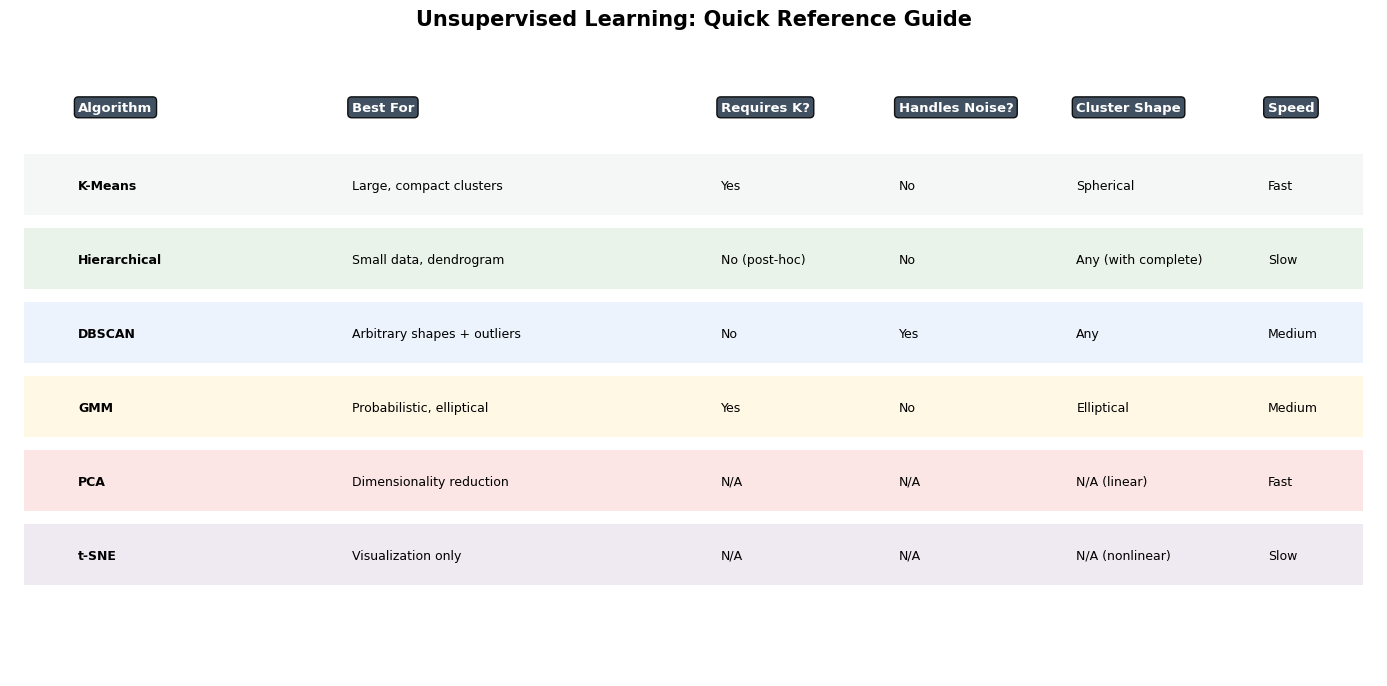

In [ ]:
# Decision guide visualization
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.set_title('Unsupervised Learning: Quick Reference Guide', fontsize=15, fontweight='bold', pad=20)

headers = ['Algorithm', 'Best For', 'Requires K?', 'Handles Noise?', 'Cluster Shape', 'Speed']
rows = [
    ['K-Means', 'Large, compact clusters', 'Yes', 'No', 'Spherical', 'Fast'],
    ['Hierarchical', 'Small data, dendrogram', 'No (post-hoc)', 'No', 'Any (with complete)', 'Slow'],
    ['DBSCAN', 'Arbitrary shapes + outliers', 'No', 'Yes', 'Any', 'Medium'],
    ['GMM', 'Probabilistic, elliptical', 'Yes', 'No', 'Elliptical', 'Medium'],
    ['PCA', 'Dimensionality reduction', 'N/A', 'N/A', 'N/A (linear)', 'Fast'],
    ['t-SNE', 'Visualization only', 'N/A', 'N/A', 'N/A (nonlinear)', 'Slow'],
]

col_positions = [0.5, 2.5, 5.2, 6.5, 7.8, 9.2]
row_colors = ['#ecf0f1', '#d5e8d4', '#dae8fc', '#fff2cc', '#f8cecc', '#e1d5e7']
header_color = '#2c3e50'

# Draw header
for ci, (header, xpos) in enumerate(zip(headers, col_positions)):
    ax.text(xpos, 7.3, header, ha='left', va='center', fontsize=9.5, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=header_color, alpha=0.9))

# Draw rows
for ri, row in enumerate(rows):
    y = 6.3 - ri * 0.95
    rect = plt.Rectangle((0.1, y - 0.38), 9.8, 0.78, facecolor=row_colors[ri], alpha=0.5, zorder=1)
    ax.add_patch(rect)
    for ci, (cell, xpos) in enumerate(zip(row, col_positions)):
        weight = 'bold' if ci == 0 else 'normal'
        ax.text(xpos, y, cell, ha='left', va='center', fontsize=9, fontweight=weight)

plt.tight_layout()
plt.show()

In [ ]:
# Final summary: all algorithms on the same dataset
print('='*70)
print('FINAL SUMMARY: Unsupervised Learning Algorithms')
print('='*70)

summary = {
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN', 'GMM', 'PCA', 't-SNE'],
    'Category': ['Clustering', 'Clustering', 'Clustering', 'Clustering', 'Dim. Reduction', 'Dim. Reduction'],
    'Key Hyperparameter': ['K (n_clusters)', 'K + linkage method', 'eps, min_samples', 'K (n_components)', 'n_components', 'perplexity'],
    'Output': ['Hard labels', 'Dendrogram + labels', 'Hard labels + noise', 'Soft probabilities', 'Low-dim representation', '2D/3D embedding'],
    'Objective': ['Minimize WCSS', 'Minimize merge distance', 'Density reachability', 'Maximize likelihood', 'Maximize variance', 'Match neighbor probs'],
}

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))
print('\nThis notebook covered the theory, math, code, and visualization for each algorithm.')
print('For production use, always start with EDA, preprocess carefully, and validate with multiple metrics.')

FINAL SUMMARY: Unsupervised Learning Algorithms
   Algorithm       Category Key Hyperparameter                 Output               Objective
     K-Means     Clustering     K (n_clusters)            Hard labels           Minimize WCSS
Hierarchical     Clustering K + linkage method    Dendrogram + labels Minimize merge distance
      DBSCAN     Clustering   eps, min_samples    Hard labels + noise    Density reachability
         GMM     Clustering   K (n_components)     Soft probabilities     Maximize likelihood
         PCA Dim. Reduction       n_components Low-dim representation       Maximize variance
       t-SNE Dim. Reduction         perplexity        2D/3D embedding    Match neighbor probs

This notebook covered the theory, math, code, and visualization for each algorithm.
For production use, always start with EDA, preprocess carefully, and validate with multiple metrics.


---

## Appendix: Key Formulas

**K-Means Inertia:**
$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

**Silhouette Score:**
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

**GMM Density:**
$$p(x) = \sum_{k=1}^{K} \pi_k \mathcal{N}(x \mid \mu_k, \Sigma_k)$$

**PCA Explained Variance Ratio:**
$$\text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}$$

**t-SNE KL Divergence (objective):**
$$KL(P \| Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$$

---

**End of Notebook.** All concepts from this notebook build directly on each other. If something is unclear, revisit the theory section for that algorithm before looking at the code. The best way to learn is to modify the code: change the dataset, change the hyperparameters, and observe what happens.
